In [1]:
!apt-get -qq update
!apt-get -qq install -y ffmpeg
!pip install -q pydub pandas openpyxl

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


In [13]:
from google.colab import files

uploaded = files.upload()

Saving atomic_sounds.zip to atomic_sounds.zip


In [14]:
import os
import zipfile

ZIP_PATH = next(iter(uploaded.keys()))
BASE_DIR = "/content/audio_dataset"

os.makedirs(BASE_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(BASE_DIR)

print("Extracted to:", BASE_DIR)

for root, dirs, files_ in os.walk(BASE_DIR):
    for f in files_:
        print(os.path.join(root, f))

Extracted to: /content/audio_dataset
/content/audio_dataset/atomic_sounds/tire_squeaking_1.aiff
/content/audio_dataset/atomic_sounds/baby_crying_1.wav
/content/audio_dataset/atomic_sounds/cat_meowing_1.mp3
/content/audio_dataset/atomic_sounds/sheep_bleating_1.wav
/content/audio_dataset/atomic_sounds/water_running_1.wav
/content/audio_dataset/atomic_sounds/wolf_howling_1.wav
/content/audio_dataset/atomic_sounds/bird_whistling_1.wav
/content/audio_dataset/atomic_sounds/smashing_glass_1.wav
/content/audio_dataset/atomic_sounds/keyboard_typing_1.mp3
/content/audio_dataset/atomic_sounds/chair_scrape_1.wav
/content/audio_dataset/atomic_sounds/elephant_trumpetting_1.mp3
/content/audio_dataset/atomic_sounds/chainsaw_1.wav
/content/audio_dataset/atomic_sounds/microwave_beep_1.wav
/content/audio_dataset/atomic_sounds/explosion_1.mp3
/content/audio_dataset/atomic_sounds/playground_1.mp3
/content/audio_dataset/atomic_sounds/phone_vibrating_1.wav
/content/audio_dataset/atomic_sounds/lightning_2.wav

In [15]:
import os

audio_count = 0

for root, dirs, files_ in os.walk("/content/audio_dataset"):
    for f in files_:
        if f.lower().endswith((
            ".wav", ".mp3", ".flac",
            ".aiff", ".aif", ".m4a",
            ".ogg", ".aac"
        )):
            audio_count += 1

print("Audio files found:", audio_count)

Audio files found: 56


In [24]:
AUDIO_EXTENSIONS = {
    ".wav", ".mp3", ".flac",
    ".aiff", ".aif", ".m4a",
    ".ogg", ".aac"
}

audio_files = []

for root, _, filenames in os.walk(BASE_DIR):
    for filename in filenames:
        ext = os.path.splitext(filename)[1].lower()

        if ext in AUDIO_EXTENSIONS:
            audio_files.append(os.path.join(root, filename))

print("Total audio files:", len(audio_files))

for f in audio_files:
    print(os.path.basename(f))

Total audio files: 56
tire_squeaking_1.aiff
baby_crying_1.wav
cat_meowing_1.mp3
sheep_bleating_1.wav
water_running_1.wav
wolf_howling_1.wav
bird_whistling_1.wav
smashing_glass_1.wav
keyboard_typing_1.mp3
chair_scrape_1.wav
elephant_trumpetting_1.mp3
chainsaw_1.wav
microwave_beep_1.wav
explosion_1.mp3
playground_1.mp3
phone_vibrating_1.wav
lightning_2.wav
child_laughing_2.mp3
horse_neighing.wav
toilet_flush_1.wav
door_bell_2.wav
man_screaming_1.wav
playground_3.wav
fire_alarm.wav
walking_1.wav
lightning_1.wav
jack_hammer.wav
door_bell_1.wav
gunshot_1.mp3
sheep_bleating_2.wav
running_1.mp3
smashing_glass_2.wav
pig_oinking_1.wav
playground_2.wav
washing_machine_2.wav
vacuum_cleaner_2.wav
child_laughing_1.wav
guitar_string_1.wav
dogs_barking_2.wav
chainsaw_2.wav
vaccuum_cleaner_1.m4a
dog-barking_1.wav
bird_whistling_2.wav
baby_crying_2.wav
cat_meowing_2.wav
washing_machine_1.wav
glass_clink.wav
drumming.wav
man_coughing_1.wav
crowd_cheering.wav
bird_wings.aiff
cow_mooing_1.wav
knock_on_doo

In [25]:
import re
import os

def get_label(filepath):

    filename = os.path.basename(filepath)

    # remove extension
    label = os.path.splitext(filename)[0]

    # remove final _1, _2, -1, etc.
    label = re.sub(r"[_-]\d+$", "", label)

    # convert separators
    label = label.replace("_", " ")
    label = label.replace("-", " ")

    return label.strip().lower()


audio_metadata = []

for filepath in audio_files:

    label = get_label(filepath)

    audio_metadata.append({
        "filepath": filepath,
        "filename": os.path.basename(filepath),
        "label": label
    })

for x in audio_metadata:
    print(x)

{'filepath': '/content/audio_dataset/atomic_sounds/tire_squeaking_1.aiff', 'filename': 'tire_squeaking_1.aiff', 'label': 'tire squeaking'}
{'filepath': '/content/audio_dataset/atomic_sounds/baby_crying_1.wav', 'filename': 'baby_crying_1.wav', 'label': 'baby crying'}
{'filepath': '/content/audio_dataset/atomic_sounds/cat_meowing_1.mp3', 'filename': 'cat_meowing_1.mp3', 'label': 'cat meowing'}
{'filepath': '/content/audio_dataset/atomic_sounds/sheep_bleating_1.wav', 'filename': 'sheep_bleating_1.wav', 'label': 'sheep bleating'}
{'filepath': '/content/audio_dataset/atomic_sounds/water_running_1.wav', 'filename': 'water_running_1.wav', 'label': 'water running'}
{'filepath': '/content/audio_dataset/atomic_sounds/wolf_howling_1.wav', 'filename': 'wolf_howling_1.wav', 'label': 'wolf howling'}
{'filepath': '/content/audio_dataset/atomic_sounds/bird_whistling_1.wav', 'filename': 'bird_whistling_1.wav', 'label': 'bird whistling'}
{'filepath': '/content/audio_dataset/atomic_sounds/smashing_glass_

In [26]:
ZERO_SHOT_HOLDOUTS = {
    "elephant trumpetting",
    "tiger roar",
    "chainsaw",
    "gunshot"
}

for item in audio_metadata:

    if item["label"] in ZERO_SHOT_HOLDOUTS:
        item["dataset_role"] = "zero_shot_holdout"
    else:
        item["dataset_role"] = "known"

print("ZERO-SHOT HOLDOUTS")

for item in audio_metadata:

    if item["dataset_role"] == "zero_shot_holdout":
        print(item["filename"], "→", item["label"])

ZERO-SHOT HOLDOUTS
elephant_trumpetting_1.mp3 → elephant trumpetting
chainsaw_1.wav → chainsaw
gunshot_1.mp3 → gunshot
chainsaw_2.wav → chainsaw
tiger_roar_1.flac → tiger roar


In [27]:
from pydub import AudioSegment
import random
import json
import numpy as np

/usr/local/lib/python3.13/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.13/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.13/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.13/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


In [28]:
SCENARIO_DIR = "/content/scenarios"

TRAIN_DIR = os.path.join(SCENARIO_DIR, "train")
VAL_DIR = os.path.join(SCENARIO_DIR, "val")
TEST_DIR = os.path.join(SCENARIO_DIR, "test")
ZERO_DIR = os.path.join(SCENARIO_DIR, "zero_shot_test")

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR, ZERO_DIR]:
    os.makedirs(d, exist_ok=True)

print("Folders created.")

Folders created.


In [29]:
from collections import defaultdict

label_to_files = defaultdict(list)

for item in audio_metadata:
    if item["dataset_role"] == "known":
        label_to_files[item["label"]].append(item["filepath"])

print("Known sound classes:", len(label_to_files))

for label, files_ in label_to_files.items():
    print(label, ":", len(files_))

Known sound classes: 40
tire squeaking : 1
baby crying : 2
cat meowing : 2
sheep bleating : 2
water running : 1
wolf howling : 1
bird whistling : 2
smashing glass : 2
keyboard typing : 1
chair scrape : 1
microwave beep : 1
explosion : 1
playground : 3
phone vibrating : 1
lightning : 2
child laughing : 2
horse neighing : 1
toilet flush : 1
door bell : 2
man screaming : 1
fire alarm : 1
walking : 1
jack hammer : 1
running : 1
pig oinking : 1
washing machine : 2
vacuum cleaner : 1
guitar string : 1
dogs barking : 1
vaccuum cleaner : 1
dog barking : 1
glass clink : 1
drumming : 1
man coughing : 1
crowd cheering : 1
bird wings : 1
cow mooing : 1
knock on door : 1
wind : 1
car horn : 1


In [30]:
import subprocess
import io
import wave
import numpy as np

def load_audio(filepath):

    command = [
        "ffmpeg",
        "-y",
        "-i", filepath,
        "-ac", "1",
        "-ar", "16000",
        "-f", "s16le",
        "-acodec", "pcm_s16le",
        "pipe:1"
    ]

    result = subprocess.run(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE
    )

    if result.returncode != 0:
        raise RuntimeError(
            f"FFmpeg failed for {filepath}\n\n"
            + result.stderr.decode(errors="ignore")
        )

    audio_array = np.frombuffer(
        result.stdout,
        dtype=np.int16
    )

    return audio_array

In [31]:
test_audio = load_audio(
    "/content/audio_dataset/atomic_sounds/baby_crying_1.wav"
)

print("Samples:", len(test_audio))
print("Duration:", len(test_audio) / 16000, "seconds")
print("Sample rate: 16000 Hz")
print("Channels: 1")

Samples: 1089228
Duration: 68.07675 seconds
Sample rate: 16000 Hz
Channels: 1


In [32]:
SCENARIO_DIR = "/content/scenarios"

TRAIN_DIR = os.path.join(SCENARIO_DIR, "train")
VAL_DIR = os.path.join(SCENARIO_DIR, "val")
TEST_DIR = os.path.join(SCENARIO_DIR, "test")
ZERO_DIR = os.path.join(SCENARIO_DIR, "zero_shot_test")

for folder in [
    TRAIN_DIR,
    VAL_DIR,
    TEST_DIR,
    ZERO_DIR
]:
    os.makedirs(folder, exist_ok=True)

print("Folders ready.")

Folders ready.


In [62]:
def choose_events(min_events=3, max_events=7):

    available_labels = list(label_to_files.keys())

    number = random.randint(
        min_events,
        min(max_events, len(available_labels))
    )

    return random.sample(
        available_labels,
        number
    )

In [63]:
def random_silence():
    # 0.2–1.5 seconds
    return random.randint(200, 1500)


def maybe_trim_audio(audio):

    max_duration = random.choice([
        3, 4, 5, 6
    ])

    max_samples = max_duration * 16000

    if len(audio) > max_samples:

        if random.random() < 0.5:
            start = 0
        else:
            start = random.randint(
                0,
                len(audio) - max_samples
            )

        audio = audio[
            start:start + max_samples
        ]

    return audio

In [64]:
import random
import os
import wave
import numpy as np

def choose_events(min_events=4, max_events=7):
    available_labels = list(label_to_files.keys())

    number = random.randint(
        min_events,
        min(max_events, len(available_labels))
    )

    # Start with unique events
    return random.sample(available_labels, number)


def choose_repetition_count():
    """
    Decide how much repetition this scenario should contain.

    50% -> no repeated event
    35% -> one event repeated once
    10% -> one event repeated twice
    5%  -> two different events repeated
    """

    r = random.random()

    if r < 0.50:
        return "none"

    elif r < 0.85:
        return "one_repeat"

    elif r < 0.95:
        return "triple_event"

    else:
        return "two_repeats"


def create_scenario(scenario_id, output_dir):

    # --------------------------------------------------
    # 1. Select unique event types
    # --------------------------------------------------

    labels = choose_events()

    # --------------------------------------------------
    # 2. Decide repetition pattern
    # --------------------------------------------------

    repetition_type = choose_repetition_count()

    event_sequence = labels.copy()

    if repetition_type == "one_repeat":

        # Pick one existing event
        repeated_label = random.choice(labels)

        # Insert another occurrence at a random position
        insert_position = random.randint(
            1,
            len(event_sequence)
        )

        event_sequence.insert(
            insert_position,
            repeated_label
        )

    elif repetition_type == "triple_event":

        # Pick one event
        repeated_label = random.choice(labels)

        # Add it twice more
        for _ in range(2):
            insert_position = random.randint(
                1,
                len(event_sequence)
            )

            event_sequence.insert(
                insert_position,
                repeated_label
            )

    elif repetition_type == "two_repeats":

        # Pick two different events
        if len(labels) >= 2:

            repeated_labels = random.sample(labels, 2)

            for repeated_label in repeated_labels:

                insert_position = random.randint(
                    1,
                    len(event_sequence)
                )

                event_sequence.insert(
                    insert_position,
                    repeated_label
                )

    # --------------------------------------------------
    # 3. Shuffle the final event order
    # --------------------------------------------------

    random.shuffle(event_sequence)

    # --------------------------------------------------
    # 4. Build audio
    # --------------------------------------------------

    audio_segments = []
    timeline = []

    current_sample = 0

    for label in event_sequence:

        filepath = random.choice(
            label_to_files[label]
        )

        audio = load_audio(filepath)

        audio = maybe_trim_audio(audio)

        # Random silence BEFORE event
        silence_duration_ms = random_silence()

        silence_samples = silence_duration_ms * 16

        silence = np.zeros(
            silence_samples,
            dtype=np.int16
        )

        audio_segments.append(silence)

        current_sample += len(silence)

        # Event start
        start = current_sample / 16000

        # Add event
        audio_segments.append(audio)

        current_sample += len(audio)

        # Event end
        end = current_sample / 16000

        timeline.append({
            "label": label,
            "start": round(start, 3),
            "end": round(end, 3)
        })

    # --------------------------------------------------
    # 5. Combine everything
    # --------------------------------------------------

    combined = np.concatenate(audio_segments)

    output_path = os.path.join(
        output_dir,
        f"{scenario_id}.wav"
    )

    with wave.open(output_path, "wb") as wav:

        wav.setnchannels(1)
        wav.setsampwidth(2)
        wav.setframerate(16000)

        wav.writeframes(
            combined.astype(np.int16).tobytes()
        )

    return {
        "scenario_id": scenario_id,
        "audio_file": output_path,
        "events": timeline,
        "repetition_type": repetition_type
    }

In [65]:
random.seed(42)

scenarios = []

# TRAIN
for i in range(100):
    scenario = create_scenario(
        f"train_{i+1:03d}",
        TRAIN_DIR
    )

    scenario["split"] = "train"
    scenarios.append(scenario)


# VALIDATION
for i in range(20):
    scenario = create_scenario(
        f"val_{i+1:03d}",
        VAL_DIR
    )

    scenario["split"] = "validation"
    scenarios.append(scenario)


# TEST
for i in range(30):
    scenario = create_scenario(
        f"test_{i+1:03d}",
        TEST_DIR
    )

    scenario["split"] = "test"
    scenarios.append(scenario)

In [37]:
for holdout in ZERO_SHOT_HOLDOUTS:

    found = []

    for scenario in scenarios:

        for event in scenario["events"]:

            if event["label"] == holdout:
                found.append(
                    scenario["scenario_id"]
                )

    print(
        holdout,
        "→",
        len(found),
        "supervised scenarios"
    )

elephant trumpetting → 0 supervised scenarios
tiger roar → 0 supervised scenarios
chainsaw → 0 supervised scenarios
gunshot → 0 supervised scenarios


In [38]:
import shutil
import os

if os.path.exists(SCENARIO_DIR):
    shutil.rmtree(SCENARIO_DIR)

for folder in [TRAIN_DIR, VAL_DIR, TEST_DIR, ZERO_DIR]:
    os.makedirs(folder, exist_ok=True)

In [39]:
from collections import Counter

for scenario in scenarios[:10]:

    labels = [
        event["label"]
        for event in scenario["events"]
    ]

    counts = Counter(labels)

    repeated = {
        label: count
        for label, count in counts.items()
        if count > 1
    }

    print("\n", scenario["scenario_id"])
    print("Sequence:")
    print(" → ".join(labels))

    print("Repeated events:", repeated)


 train_001
Sequence:
toilet flush → lightning → child laughing → baby crying
Repeated events: {}

 train_002
Sequence:
pig oinking → wolf howling → bird wings → bird whistling → bird whistling → jack hammer → car horn
Repeated events: {'bird whistling': 2}

 train_003
Sequence:
toilet flush → fire alarm → cat meowing → washing machine → water running
Repeated events: {}

 train_004
Sequence:
wind → man coughing → vaccuum cleaner → pig oinking
Repeated events: {}

 train_005
Sequence:
baby crying → wind → fire alarm → glass clink
Repeated events: {}

 train_006
Sequence:
running → man coughing → knock on door → smashing glass → dogs barking → washing machine
Repeated events: {}

 train_007
Sequence:
guitar string → vacuum cleaner → jack hammer → bird whistling
Repeated events: {}

 train_008
Sequence:
microwave beep → wolf howling → vacuum cleaner → child laughing
Repeated events: {}

 train_009
Sequence:
car horn → microwave beep → explosion → sheep bleating → man coughing → wolf howl

In [40]:
import json

with open("/content/scenarios.json", "w") as f:
    json.dump(scenarios, f, indent=2)

print("Saved", len(scenarios), "scenarios")

Saved 150 scenarios


qa pairs

In [41]:
from collections import Counter

qa_rows = []


def add_qa(scenario, question, answer, question_type):

    qa_rows.append({
        "scenario_id": scenario["scenario_id"],
        "audio_file": scenario["audio_file"],
        "question": question,
        "question_type": question_type,
        "answer": str(answer),
        "split": scenario["split"]
    })

In [42]:
def generate_perceptual_qa(scenario):

    events = scenario["events"]

    labels = list(
        dict.fromkeys(
            event["label"]
            for event in events
        )
    )

    answer = ", ".join(labels)

    add_qa(
        scenario,
        "What sounds are present in the audio?",
        answer,
        "perceptual"
    )

In [43]:
def generate_counting_qa(scenario):

    labels = [
        event["label"]
        for event in scenario["events"]
    ]

    counts = Counter(labels)

    for label, count in counts.items():

        add_qa(
            scenario,
            f"How many times does {label} occur?",
            count,
            "counting"
        )

In [44]:
def generate_temporal_qa(scenario):

    events = sorted(
        scenario["events"],
        key=lambda x: x["start"]
    )

    # First
    add_qa(
        scenario,
        "What sound occurs first?",
        events[0]["label"],
        "temporal"
    )

    # Last
    add_qa(
        scenario,
        "What sound occurs last?",
        events[-1]["label"],
        "temporal"
    )

    # Only generate adjacent-event questions
    # when the source label occurs only once.
    label_counts = Counter(
        event["label"]
        for event in events
    )

    for i in range(len(events) - 1):

        current = events[i]["label"]
        next_event = events[i + 1]["label"]

        if label_counts[current] == 1:

            add_qa(
                scenario,
                f"What sound occurs immediately after {current}?",
                next_event,
                "temporal"
            )

        if label_counts[next_event] == 1:

            add_qa(
                scenario,
                f"What sound occurs immediately before {next_event}?",
                current,
                "temporal"
            )

In [45]:
for scenario in scenarios:

    generate_perceptual_qa(scenario)

    generate_counting_qa(scenario)

    generate_temporal_qa(scenario)

In [46]:
import pandas as pd

qa_df = pd.DataFrame(qa_rows)

print("Total QA pairs:", len(qa_df))

display(qa_df.head(20))

Total QA pairs: 2502


,scenario_id,audio_file,question,question_type,answer,split
0,train_001,/content/scenarios/train/train_001.wav,What sounds are present in the audio?,perceptual,"toilet flush, lightning, child laughing, baby ...",train
1,train_001,/content/scenarios/train/train_001.wav,How many times does toilet flush occur?,counting,1,train
2,train_001,/content/scenarios/train/train_001.wav,How many times does lightning occur?,counting,1,train
3,train_001,/content/scenarios/train/train_001.wav,How many times does child laughing occur?,counting,1,train
4,train_001,/content/scenarios/train/train_001.wav,How many times does baby crying occur?,counting,1,train
5,train_001,/content/scenarios/train/train_001.wav,What sound occurs first?,temporal,toilet flush,train
6,train_001,/content/scenarios/train/train_001.wav,What sound occurs last?,temporal,baby crying,train
7,train_001,/content/scenarios/train/train_001.wav,What sound occurs immediately after toilet flush?,temporal,lightning,train
8,train_001,/content/scenarios/train/train_001.wav,What sound occurs immediately before lightning?,temporal,toilet flush,train
9,train_001,/content/scenarios/train/train_001.wav,What sound occurs immediately after lightning?,temporal,child laughing,train


In [47]:
print(
    qa_df["question_type"].value_counts()
)

question_type
temporal      1537
counting       815
perceptual     150
Name: count, dtype: int64


In [48]:
qa_df.to_csv(
    "/content/qa_dataset.csv",
    index=False
)

print("QA dataset saved!")

QA dataset saved!


0 shot generator

In [66]:
def create_zero_shot_scenario(scenario_id, holdout_label):

    known_labels = list(label_to_files.keys())

    # 2–3 known sounds
    supporting_labels = random.sample(
        known_labels,
        random.randint(2, 3)
    )

    # Create event sequence
    event_sequence = supporting_labels + [holdout_label]

    # Randomize order
    random.shuffle(event_sequence)

    audio_segments = []
    timeline = []

    current_sample = 0

    for label in event_sequence:

        # Choose appropriate source
        if label == holdout_label:

            candidates = [
                x["filepath"]
                for x in audio_metadata
                if x["label"] == label
                and x["dataset_role"] == "zero_shot_holdout"
            ]

        else:

            candidates = label_to_files[label]

        filepath = random.choice(candidates)

        audio = load_audio(filepath)
        audio = maybe_trim_audio(audio)

        # Silence before event
        silence_samples = random_silence() * 16

        silence = np.zeros(
            silence_samples,
            dtype=np.int16
        )

        audio_segments.append(silence)
        current_sample += len(silence)

        # Event start
        start = current_sample / 16000

        # Event
        audio_segments.append(audio)
        current_sample += len(audio)

        # Event end
        end = current_sample / 16000

        timeline.append({
            "label": label,
            "start": round(start, 3),
            "end": round(end, 3),
            "zero_shot": label == holdout_label
        })

    # Combine
    combined = np.concatenate(audio_segments)

    output_path = os.path.join(
        ZERO_DIR,
        f"{scenario_id}.wav"
    )

    with wave.open(output_path, "wb") as wav:

        wav.setnchannels(1)
        wav.setsampwidth(2)
        wav.setframerate(16000)

        wav.writeframes(
            combined.astype(np.int16).tobytes()
        )

    return {
        "scenario_id": scenario_id,
        "audio_file": output_path,
        "events": timeline,
        "split": "zero_shot_test",
        "held_out_class": holdout_label
    }

In [50]:
ZERO_SHOT_HOLDOUTS = {
    "elephant trumpetting",
    "tiger roar",
    "chainsaw",
    "gunshot"
}

In [51]:
zero_shot_scenarios = []

random.seed(42)

for holdout in ZERO_SHOT_HOLDOUTS:

    for i in range(5):

        scenario = create_zero_shot_scenario(
            f"zs_{holdout.replace(' ', '_')}_{i+1:02d}",
            holdout
        )

        zero_shot_scenarios.append(scenario)

print(
    "Zero-shot scenarios:",
    len(zero_shot_scenarios)
)

Zero-shot scenarios: 20


In [52]:
for holdout in ZERO_SHOT_HOLDOUTS:

    supervised_occurrences = []

    for scenario in scenarios:

        for event in scenario["events"]:

            if event["label"] == holdout:
                supervised_occurrences.append(
                    scenario["scenario_id"]
                )

    print(
        holdout,
        "in supervised data:",
        len(supervised_occurrences)
    )

elephant trumpetting in supervised data: 0
tiger roar in supervised data: 0
chainsaw in supervised data: 0
gunshot in supervised data: 0


In [53]:
for scenario in zero_shot_scenarios:

    print(
        scenario["scenario_id"],
        "→",
        scenario["held_out_class"]
    )

zs_elephant_trumpetting_01 → elephant trumpetting
zs_elephant_trumpetting_02 → elephant trumpetting
zs_elephant_trumpetting_03 → elephant trumpetting
zs_elephant_trumpetting_04 → elephant trumpetting
zs_elephant_trumpetting_05 → elephant trumpetting
zs_tiger_roar_01 → tiger roar
zs_tiger_roar_02 → tiger roar
zs_tiger_roar_03 → tiger roar
zs_tiger_roar_04 → tiger roar
zs_tiger_roar_05 → tiger roar
zs_chainsaw_01 → chainsaw
zs_chainsaw_02 → chainsaw
zs_chainsaw_03 → chainsaw
zs_chainsaw_04 → chainsaw
zs_chainsaw_05 → chainsaw
zs_gunshot_01 → gunshot
zs_gunshot_02 → gunshot
zs_gunshot_03 → gunshot
zs_gunshot_04 → gunshot
zs_gunshot_05 → gunshot


In [54]:
all_scenarios = scenarios + zero_shot_scenarios

with open("/content/scenarios.json", "w") as f:
    json.dump(all_scenarios, f, indent=2)

print(
    "Total scenarios:",
    len(all_scenarios)
)

Total scenarios: 170


In [55]:
from collections import Counter

print(
    Counter(
        s["split"]
        for s in all_scenarios
    )
)

Counter({'train': 100, 'test': 30, 'validation': 20, 'zero_shot_test': 20})


clap embedding

In [56]:
!pip install -q transformers torch torchaudio

In [57]:
import torch
from transformers import ClapModel, ClapProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = ClapProcessor.from_pretrained(
    "laion/clap-htsat-unfused"
)

model = ClapModel.from_pretrained(
    "laion/clap-htsat-unfused"
).to(device)

model.eval()

print("Device:", device)

Loading weights:   0%|          | 0/447 [00:00<?, ?it/s]

Device: cpu


In [58]:
def get_clap_audio_embedding(filepath):

    # Load our 16 kHz audio
    audio = load_audio(filepath)

    # Convert int16 -> float32
    audio = audio.astype(np.float32) / 32768.0

    # ------------------------------------------------
    # Resample 16 kHz -> 48 kHz
    # ------------------------------------------------

    audio_tensor = torch.from_numpy(audio).float()
    audio_tensor = audio_tensor.unsqueeze(0).unsqueeze(1)

    audio_48k = torch.nn.functional.interpolate(
        audio_tensor,
        scale_factor=3,
        mode="linear",
        align_corners=False
    )

    audio_48k = audio_48k.squeeze().numpy()

    # ------------------------------------------------
    # CLAP preprocessing
    # ------------------------------------------------

    inputs = processor(
        audio=audio_48k,
        sampling_rate=48000,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    # ------------------------------------------------
    # Get CLAP audio representation
    # ------------------------------------------------

    with torch.no_grad():

        outputs = model.get_audio_features(
            **inputs
        )

    # ------------------------------------------------
    # Handle Transformers output
    # ------------------------------------------------

    if isinstance(outputs, torch.Tensor):

        embedding = outputs

    elif hasattr(outputs, "pooler_output"):

        embedding = outputs.pooler_output

    elif hasattr(outputs, "last_hidden_state"):

        embedding = outputs.last_hidden_state.mean(
            dim=1
        )

    else:

        raise TypeError(
            f"Unexpected CLAP output type: {type(outputs)}"
        )

    # ------------------------------------------------
    # Normalize embedding
    # ------------------------------------------------

    embedding = embedding / embedding.norm(
        dim=-1,
        keepdim=True
    )

    return embedding.squeeze(0).cpu().numpy()

In [59]:
import os

for root, dirs, files in os.walk("/content"):
    for f in files:
        if "baby_crying_1" in f.lower():
            print(os.path.join(root, f))

/content/audio_dataset/atomic_sounds/baby_crying_1.wav


In [60]:
test_audio = "/content/audio_dataset/atomic_sounds/baby_crying_1.wav"

audio_emb = get_clap_audio_embedding(test_audio)

print("Embedding shape:", audio_emb.shape)
print("Embedding norm:", np.linalg.norm(audio_emb))

Embedding shape: (512,)
Embedding norm: 1.0


In [67]:
scenario_embeddings = {}

for i, scenario in enumerate(all_scenarios):

    filepath = scenario["audio_file"]

    embedding = get_clap_audio_embedding(filepath)

    scenario_embeddings[
        scenario["scenario_id"]
    ] = embedding

    if (i + 1) % 10 == 0:
        print(
            f"Processed {i+1}/{len(all_scenarios)}"
        )

Processed 10/170
Processed 20/170
Processed 30/170
Processed 40/170
Processed 50/170
Processed 60/170
Processed 70/170
Processed 80/170
Processed 90/170
Processed 100/170
Processed 110/170
Processed 120/170
Processed 130/170
Processed 140/170
Processed 150/170
Processed 160/170
Processed 170/170


In [68]:
import pickle

with open(
    "/content/scenario_clap_embeddings.pkl",
    "wb"
) as f:

    pickle.dump(
        scenario_embeddings,
        f
    )

print("CLAP embeddings saved.")

CLAP embeddings saved.


In [113]:
def get_clap_text_embedding(text):

    inputs = processor(
        text=[text],
        return_tensors="pt",
        padding=True
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = model.get_text_features(
            **inputs
        )

    # Handle different Transformers versions
    if isinstance(outputs, torch.Tensor):
        embedding = outputs

    elif hasattr(outputs, "pooler_output"):
        embedding = outputs.pooler_output

    elif hasattr(outputs, "text_embeds"):
        embedding = outputs.text_embeds

    elif hasattr(outputs, "last_hidden_state"):
        embedding = outputs.last_hidden_state.mean(dim=1)

    else:
        raise TypeError(
            f"Unexpected CLAP text output type: {type(outputs)}"
        )

    # Normalize
    embedding = embedding / embedding.norm(
        dim=-1,
        keepdim=True
    )

    return embedding.squeeze(0).cpu().numpy()

In [114]:
test_question = "How many times does keyboard typing occur?"

question_embedding = get_clap_text_embedding(
    test_question
)

print("Shape:", question_embedding.shape)

Shape: (512,)


In [115]:
unique_questions = qa_df["question"].unique()

question_embeddings = {}

for i, question in enumerate(unique_questions):

    question_embeddings[question] = (
        get_clap_text_embedding(question)
    )

    if (i + 1) % 50 == 0:
        print(
            f"Encoded {i+1}/{len(unique_questions)} questions"
        )

print(
    "Total unique questions:",
    len(question_embeddings)
)

Encoded 50/123 questions
Encoded 100/123 questions
Total unique questions: 123


In [72]:
import numpy as np

X_audio = []
X_question = []
question_types = []
answers = []
splits = []
scenario_ids = []

for _, row in qa_df.iterrows():

    audio_emb = scenario_embeddings[
        row["scenario_id"]
    ]

    question_emb = question_embeddings[
        row["question"]
    ]

    X_audio.append(audio_emb)
    X_question.append(question_emb)

    question_types.append(
        row["question_type"]
    )

    answers.append(
        row["answer"]
    )

    splits.append(
        row["split"]
    )

    scenario_ids.append(
        row["scenario_id"]
    )

X_audio = np.array(X_audio)
X_question = np.array(X_question)

print("Audio:", X_audio.shape)
print("Question:", X_question.shape)

Audio: (2502, 512)
Question: (2502, 512)


model

In [73]:
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np

# --------------------------------------------------
# Sound vocabulary
# --------------------------------------------------

known_labels = sorted(label_to_files.keys())

label_to_id = {
    label: i
    for i, label in enumerate(known_labels)
}

id_to_label = {
    i: label
    for label, i in label_to_id.items()
}

num_labels = len(known_labels)

print("Number of sound classes:", num_labels)


# --------------------------------------------------
# Counting classes
# --------------------------------------------------

count_classes = [1, 2, 3]

count_to_id = {
    count: i
    for i, count in enumerate(count_classes)
}

id_to_count = {
    i: count
    for count, i in count_to_id.items()
}

Number of sound classes: 40


In [74]:
def make_perceptual_target(answer):

    labels = [
        x.strip()
        for x in answer.split(",")
    ]

    target = np.zeros(
        num_labels,
        dtype=np.float32
    )

    for label in labels:

        if label in label_to_id:
            target[label_to_id[label]] = 1.0

    return target

In [75]:
import torch

audio_features = []
question_features = []

perceptual_targets = []
count_targets = []
temporal_targets = []

question_type_ids = []
split_list = []

for i, row in qa_df.iterrows():

    audio_features.append(
        X_audio[i]
    )

    question_features.append(
        X_question[i]
    )

    qtype = row["question_type"]

    # ----------------------------------------------
    # Perceptual
    # ----------------------------------------------

    if qtype == "perceptual":

        perceptual_targets.append(
            make_perceptual_target(
                row["answer"]
            )
        )

        count_targets.append(-1)
        temporal_targets.append(-1)

    # ----------------------------------------------
    # Counting
    # ----------------------------------------------

    elif qtype == "counting":

        perceptual_targets.append(
            np.zeros(num_labels, dtype=np.float32)
        )

        count_targets.append(
            count_to_id[int(row["answer"])]
        )

        temporal_targets.append(-1)

    # ----------------------------------------------
    # Temporal
    # ----------------------------------------------

    elif qtype == "temporal":

        perceptual_targets.append(
            np.zeros(num_labels, dtype=np.float32)
        )

        count_targets.append(-1)

        temporal_targets.append(
            label_to_id[row["answer"]]
        )

    question_type_ids.append(qtype)

    split_list.append(row["split"])


audio_features = torch.tensor(
    np.array(audio_features),
    dtype=torch.float32
)

question_features = torch.tensor(
    np.array(question_features),
    dtype=torch.float32
)

perceptual_targets = torch.tensor(
    np.array(perceptual_targets),
    dtype=torch.float32
)

count_targets = torch.tensor(
    count_targets,
    dtype=torch.long
)

temporal_targets = torch.tensor(
    temporal_targets,
    dtype=torch.long
)

print("Audio:", audio_features.shape)
print("Question:", question_features.shape)
print("Perceptual:", perceptual_targets.shape)
print("Counting:", count_targets.shape)
print("Temporal:", temporal_targets.shape)

Audio: torch.Size([2502, 512])
Question: torch.Size([2502, 512])
Perceptual: torch.Size([2502, 40])
Counting: torch.Size([2502])
Temporal: torch.Size([2502])


In [76]:
train_indices = [
    i for i, split in enumerate(split_list)
    if split == "train"
]

val_indices = [
    i for i, split in enumerate(split_list)
    if split == "validation"
]

test_indices = [
    i for i, split in enumerate(split_list)
    if split == "test"
]

print("Train QA:", len(train_indices))
print("Validation QA:", len(val_indices))
print("Test QA:", len(test_indices))

Train QA: 1674
Validation QA: 332
Test QA: 496


In [77]:
import torch.nn as nn


class AudioQAModel(nn.Module):

    def __init__(
        self,
        embedding_dim,
        num_labels,
        num_count_classes=3,
        hidden_dim=256
    ):

        super().__init__()

        # ------------------------------------------
        # Audio projection
        # ------------------------------------------

        self.audio_projection = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # ------------------------------------------
        # Question projection
        # ------------------------------------------

        self.question_projection = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # ------------------------------------------
        # Fusion
        # ------------------------------------------

        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # ------------------------------------------
        # Question-specific heads
        # ------------------------------------------

        self.perceptual_head = nn.Linear(
            hidden_dim,
            num_labels
        )

        self.counting_head = nn.Linear(
            hidden_dim,
            num_count_classes
        )

        self.temporal_head = nn.Linear(
            hidden_dim,
            num_labels
        )

    def forward(
        self,
        audio,
        question
    ):

        audio_features = self.audio_projection(
            audio
        )

        question_features = self.question_projection(
            question
        )

        fused = torch.cat(
            [
                audio_features,
                question_features
            ],
            dim=1
        )

        fused = self.fusion(fused)

        return {
            "perceptual": self.perceptual_head(fused),
            "counting": self.counting_head(fused),
            "temporal": self.temporal_head(fused)
        }

In [78]:
embedding_dim = audio_features.shape[1]

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

qa_model = AudioQAModel(
    embedding_dim=embedding_dim,
    num_labels=num_labels
).to(device)

print(qa_model)

AudioQAModel(
  (audio_projection): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (question_projection): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (fusion): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (perceptual_head): Linear(in_features=256, out_features=40, bias=True)
  (counting_head): Linear(in_features=256, out_features=3, bias=True)
  (temporal_head): Linear(in_features=256, out_features=40, bias=True)
)


In [79]:
##data loaders
from torch.utils.data import TensorDataset, DataLoader

def make_dataset(indices):

    return TensorDataset(
        audio_features[indices],
        question_features[indices],
        perceptual_targets[indices],
        count_targets[indices],
        temporal_targets[indices]
    )


train_dataset = make_dataset(train_indices)
val_dataset = make_dataset(val_indices)
test_dataset = make_dataset(test_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 53
Validation batches: 11
Test batches: 16


In [80]:
perceptual_loss_fn = nn.BCEWithLogitsLoss()

counting_loss_fn = nn.CrossEntropyLoss()

temporal_loss_fn = nn.CrossEntropyLoss()

In [81]:
optimizer = torch.optim.AdamW(
    qa_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [82]:
def train_one_epoch(model, loader):

    model.train()

    total_loss = 0.0
    total_batches = 0

    for (
        audio,
        question,
        perceptual_target,
        count_target,
        temporal_target
    ) in loader:

        audio = audio.to(device)
        question = question.to(device)

        perceptual_target = perceptual_target.to(device)
        count_target = count_target.to(device)
        temporal_target = temporal_target.to(device)

        optimizer.zero_grad()

        outputs = model(
            audio,
            question
        )

        loss = 0.0

        # ------------------------------------------
        # Perceptual loss
        # ------------------------------------------

        perceptual_mask = (
            count_target == -1
        ) & (
            temporal_target == -1
        )

        if perceptual_mask.any():

            p_loss = perceptual_loss_fn(
                outputs["perceptual"][perceptual_mask],
                perceptual_target[perceptual_mask]
            )

            loss = loss + p_loss

        # ------------------------------------------
        # Counting loss
        # ------------------------------------------

        count_mask = count_target != -1

        if count_mask.any():

            c_loss = counting_loss_fn(
                outputs["counting"][count_mask],
                count_target[count_mask]
            )

            loss = loss + c_loss

        # ------------------------------------------
        # Temporal loss
        # ------------------------------------------

        temporal_mask = temporal_target != -1

        if temporal_mask.any():

            t_loss = temporal_loss_fn(
                outputs["temporal"][temporal_mask],
                temporal_target[temporal_mask]
            )

            loss = loss + t_loss

        # ------------------------------------------
        # Backpropagation
        # ------------------------------------------

        loss.backward()

        optimizer.step()

        total_loss += loss.item()
        total_batches += 1

    return total_loss / total_batches

In [83]:
def evaluate_loss(model, loader):

    model.eval()

    total_loss = 0.0
    total_batches = 0

    with torch.no_grad():

        for (
            audio,
            question,
            perceptual_target,
            count_target,
            temporal_target
        ) in loader:

            audio = audio.to(device)
            question = question.to(device)

            perceptual_target = perceptual_target.to(device)
            count_target = count_target.to(device)
            temporal_target = temporal_target.to(device)

            outputs = model(
                audio,
                question
            )

            loss = 0.0

            # Perceptual
            perceptual_mask = (
                count_target == -1
            ) & (
                temporal_target == -1
            )

            if perceptual_mask.any():

                loss += perceptual_loss_fn(
                    outputs["perceptual"][perceptual_mask],
                    perceptual_target[perceptual_mask]
                )

            # Counting
            count_mask = count_target != -1

            if count_mask.any():

                loss += counting_loss_fn(
                    outputs["counting"][count_mask],
                    count_target[count_mask]
                )

            # Temporal
            temporal_mask = temporal_target != -1

            if temporal_mask.any():

                loss += temporal_loss_fn(
                    outputs["temporal"][temporal_mask],
                    temporal_target[temporal_mask]
                )

            total_loss += loss.item()
            total_batches += 1

    return total_loss / total_batches

In [84]:
num_epochs = 30

train_losses = []
val_losses = []

best_val_loss = float("inf")

for epoch in range(num_epochs):

    train_loss = train_one_epoch(
        qa_model,
        train_loader
    )

    val_loss = evaluate_loss(
        qa_model,
        val_loader
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            qa_model.state_dict(),
            "/content/best_audio_qa_model.pt"
        )

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 01/30 | Train Loss: 4.5749 | Val Loss: 4.4083
Epoch 02/30 | Train Loss: 4.3620 | Val Loss: 4.3571
Epoch 03/30 | Train Loss: 4.2319 | Val Loss: 4.3349
Epoch 04/30 | Train Loss: 4.0728 | Val Loss: 4.3393
Epoch 05/30 | Train Loss: 3.9378 | Val Loss: 4.3883
Epoch 06/30 | Train Loss: 3.7723 | Val Loss: 4.4707
Epoch 07/30 | Train Loss: 3.6321 | Val Loss: 4.5397
Epoch 08/30 | Train Loss: 3.5409 | Val Loss: 4.5136
Epoch 09/30 | Train Loss: 3.4724 | Val Loss: 4.5746
Epoch 10/30 | Train Loss: 3.3743 | Val Loss: 4.5911
Epoch 11/30 | Train Loss: 3.2690 | Val Loss: 4.6366
Epoch 12/30 | Train Loss: 3.1502 | Val Loss: 4.7551
Epoch 13/30 | Train Loss: 3.0777 | Val Loss: 4.7566
Epoch 14/30 | Train Loss: 3.0535 | Val Loss: 4.7680
Epoch 15/30 | Train Loss: 2.9325 | Val Loss: 4.8502
Epoch 16/30 | Train Loss: 2.8544 | Val Loss: 4.9295
Epoch 17/30 | Train Loss: 2.7699 | Val Loss: 5.0151
Epoch 18/30 | Train Loss: 2.7127 | Val Loss: 5.0651
Epoch 19/30 | Train Loss: 2.6347 | Val Loss: 5.0624
Epoch 20/30 

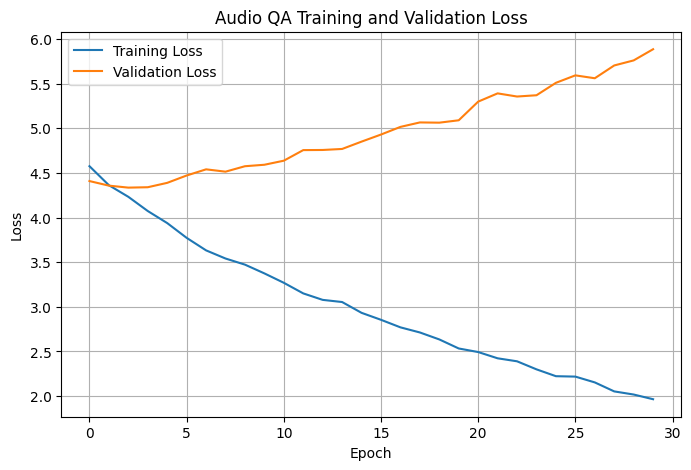

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Audio QA Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [86]:
plt.savefig(
    "/content/audio_qa_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [87]:
# Load the model with the lowest validation loss
qa_model.load_state_dict(
    torch.load(
        "/content/best_audio_qa_model.pt",
        map_location=device
    )
)

qa_model.eval()

print("Best validation model loaded.")

Best validation model loaded.


In [88]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np


def evaluate_model(model, loader):

    model.eval()

    perceptual_true = []
    perceptual_pred = []

    count_true = []
    count_pred = []

    temporal_true = []
    temporal_pred = []

    with torch.no_grad():

        for (
            audio,
            question,
            perceptual_target,
            count_target,
            temporal_target
        ) in loader:

            audio = audio.to(device)
            question = question.to(device)

            outputs = model(
                audio,
                question
            )

            # --------------------------------------
            # Perceptual
            # --------------------------------------

            perceptual_mask = (
                count_target == -1
            ) & (
                temporal_target == -1
            )

            if perceptual_mask.any():

                logits = outputs["perceptual"][
                    perceptual_mask
                ]

                predictions = (
                    torch.sigmoid(logits) >= 0.5
                ).cpu().numpy()

                targets = (
                    perceptual_target[perceptual_mask]
                    .numpy()
                )

                perceptual_pred.extend(predictions)
                perceptual_true.extend(targets)

            # --------------------------------------
            # Counting
            # --------------------------------------

            count_mask = count_target != -1

            if count_mask.any():

                predictions = torch.argmax(
                    outputs["counting"][count_mask],
                    dim=1
                ).cpu().numpy()

                targets = (
                    count_target[count_mask]
                    .numpy()
                )

                count_pred.extend(predictions)
                count_true.extend(targets)

            # --------------------------------------
            # Temporal
            # --------------------------------------

            temporal_mask = temporal_target != -1

            if temporal_mask.any():

                predictions = torch.argmax(
                    outputs["temporal"][temporal_mask],
                    dim=1
                ).cpu().numpy()

                targets = (
                    temporal_target[temporal_mask]
                    .numpy()
                )

                temporal_pred.extend(predictions)
                temporal_true.extend(targets)

    # ----------------------------------------------
    # Metrics
    # ----------------------------------------------

    perceptual_f1 = f1_score(
        perceptual_true,
        perceptual_pred,
        average="micro",
        zero_division=0
    )

    counting_accuracy = accuracy_score(
        count_true,
        count_pred
    )

    temporal_accuracy = accuracy_score(
        temporal_true,
        temporal_pred
    )

    return {
        "perceptual_f1": perceptual_f1,
        "counting_accuracy": counting_accuracy,
        "temporal_accuracy": temporal_accuracy
    }

In [89]:
results = evaluate_model(
    qa_model,
    test_loader
)

print("Supervised Test Results")
print("-----------------------")

for metric, value in results.items():
    print(
        f"{metric}: {value:.4f}"
    )

Supervised Test Results
-----------------------
perceptual_f1: 0.0000
counting_accuracy: 0.8773
temporal_accuracy: 0.0561


In [91]:
print("Test QA pairs:", len(test_indices))

print(
    qa_df.iloc[test_indices]["question_type"].value_counts()
)

Test QA pairs: 496
question_type
temporal      303
counting      163
perceptual     30
Name: count, dtype: int64


In [92]:
##early stopping
num_epochs = 20
patience = 4

train_losses = []
val_losses = []

best_val_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(num_epochs):

    train_loss = train_one_epoch(
        qa_model,
        train_loader
    )

    val_loss = evaluate_loss(
        qa_model,
        val_loader
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        epochs_without_improvement = 0

        torch.save(
            qa_model.state_dict(),
            "/content/best_audio_qa_model_v2.pt"
        )

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping triggered.")
        break

Epoch 01/20 | Train Loss: 4.1087 | Val Loss: 4.3395
Epoch 02/20 | Train Loss: 4.0663 | Val Loss: 4.3438
Epoch 03/20 | Train Loss: 3.9600 | Val Loss: 4.3838
Epoch 04/20 | Train Loss: 3.8614 | Val Loss: 4.3948
Epoch 05/20 | Train Loss: 3.7532 | Val Loss: 4.4140
Early stopping triggered.


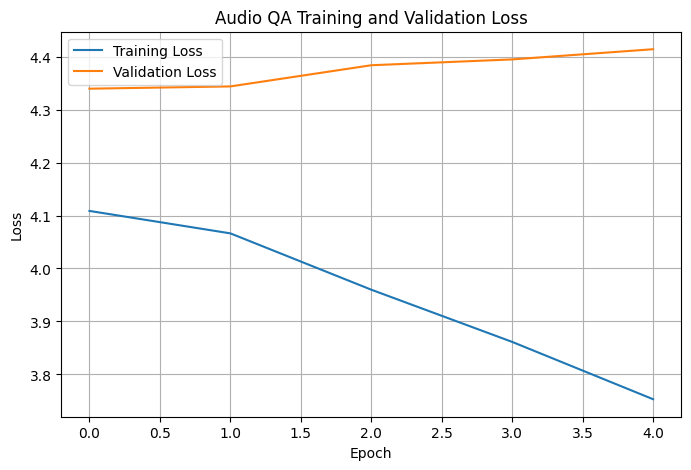

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Audio QA Training and Validation Loss")

plt.legend()
plt.grid(True)
plt.show()

In [94]:
qa_model.load_state_dict(
    torch.load(
        "/content/best_audio_qa_model_v2.pt",
        map_location=device
    )
)

qa_model.eval()

print("Best validation model loaded.")

Best validation model loaded.


In [95]:
results = evaluate_model(
    qa_model,
    test_loader
)

print("Supervised Test Results")
print("-----------------------")

for metric, value in results.items():
    print(f"{metric}: {value:.4f}")

Supervised Test Results
-----------------------
perceptual_f1: 0.0000
counting_accuracy: 0.8773
temporal_accuracy: 0.0594


In [96]:
print("Test QA pairs:", len(test_indices))

print(
    qa_df.iloc[test_indices]["question_type"].value_counts()
)

Test QA pairs: 496
question_type
temporal      303
counting      163
perceptual     30
Name: count, dtype: int64


In [98]:
batch = next(iter(test_loader))

print(type(batch))
print(len(batch))

for i, item in enumerate(batch):
    print(i, type(item), getattr(item, "shape", None))

<class 'list'>
5
0 <class 'torch.Tensor'> torch.Size([32, 512])
1 <class 'torch.Tensor'> torch.Size([32, 512])
2 <class 'torch.Tensor'> torch.Size([32, 40])
3 <class 'torch.Tensor'> torch.Size([32])
4 <class 'torch.Tensor'> torch.Size([32])


In [100]:
import torch
from sklearn.metrics import f1_score

qa_model.eval()

all_probs = []
all_targets = []

with torch.no_grad():
    for batch in test_loader:

        audio = batch[0].to(device)
        question = batch[1].to(device)

        outputs = qa_model(audio, question)

        probs = torch.sigmoid(outputs["perceptual"])

        all_probs.append(probs.cpu())
        all_targets.append(batch[2].cpu())

all_probs = torch.cat(all_probs)
all_targets = torch.cat(all_targets)

print("Probability min:", all_probs.min().item())
print("Probability max:", all_probs.max().item())
print("Probability mean:", all_probs.mean().item())
print("Target positives:", all_targets.sum().item())
print("Shape:", all_probs.shape)

Probability min: 0.0543697327375412
Probability max: 0.41383096575737
Probability mean: 0.21882477402687073
Target positives: 163.0
Shape: torch.Size([496, 40])


In [101]:
import numpy as np
from sklearn.metrics import f1_score

print("\nPerceptual F1 at different thresholds:")
print("--------------------------------------")

for threshold in [0.1, 0.2, 0.3, 0.4, 0.5]:

    preds = (all_probs.numpy() >= threshold).astype(int)

    f1 = f1_score(
        all_targets.numpy(),
        preds,
        average="micro",
        zero_division=0
    )

    print(f"Threshold {threshold:.1f}: F1 = {f1:.4f}")


Perceptual F1 at different thresholds:
--------------------------------------
Threshold 0.1: F1 = 0.0136
Threshold 0.2: F1 = 0.0014
Threshold 0.3: F1 = 0.0000
Threshold 0.4: F1 = 0.0000
Threshold 0.5: F1 = 0.0000


In [102]:
import torch
import numpy as np

qa_model.eval()

perceptual_probs = []
perceptual_targets = []

with torch.no_grad():
    for batch in test_loader:
        audio = batch[0].to(device)
        question = batch[1].to(device)

        outputs = qa_model(audio, question)

        probs = torch.sigmoid(outputs["perceptual"]).cpu()
        targets = batch[2].cpu()

        # Keep only actual perceptual QA rows
        mask = targets.sum(dim=1) > 0

        perceptual_probs.append(probs[mask])
        perceptual_targets.append(targets[mask])

perceptual_probs = torch.cat(perceptual_probs)
perceptual_targets = torch.cat(perceptual_targets)

print("Perceptual samples:", len(perceptual_probs))
print("Target shape:", perceptual_targets.shape)
print("Target positives:", perceptual_targets.sum().item())
print("Predicted probability mean:", perceptual_probs.mean().item())
print("Predicted probability max:", perceptual_probs.max().item())

Perceptual samples: 30
Target shape: torch.Size([30, 40])
Target positives: 163.0
Predicted probability mean: 0.13362382352352142
Predicted probability max: 0.2759421169757843


In [103]:
# Inspect the first 5 perceptual samples

for i in range(min(5, len(perceptual_probs))):

    true_indices = torch.where(perceptual_targets[i] > 0)[0].tolist()

    top_values, top_indices = torch.topk(
        perceptual_probs[i],
        k=5
    )

    print(f"\nSample {i}")
    print("True label indices:", true_indices)
    print("Top predicted indices:", top_indices.tolist())
    print("Top predicted probabilities:",
          [round(x, 4) for x in top_values.tolist()])


Sample 0
True label indices: [1, 5, 15, 30, 31, 39]
Top predicted indices: [1, 3, 33, 12, 28]
Top predicted probabilities: [0.2444, 0.2222, 0.19, 0.1856, 0.18]

Sample 1
True label indices: [2, 6, 9, 13, 17, 32]
Top predicted indices: [1, 3, 23, 28, 33]
Top predicted probabilities: [0.2759, 0.207, 0.1947, 0.1832, 0.1801]

Sample 2
True label indices: [2, 3, 17, 18, 20, 28]
Top predicted indices: [1, 3, 33, 12, 28]
Top predicted probabilities: [0.2555, 0.1753, 0.1702, 0.1699, 0.1595]

Sample 3
True label indices: [3, 10, 28, 32, 36, 38]
Top predicted indices: [1, 3, 23, 33, 12]
Top predicted probabilities: [0.2643, 0.2552, 0.2209, 0.2085, 0.2013]

Sample 4
True label indices: [0, 4, 9, 14, 18]
Top predicted indices: [1, 3, 33, 23, 16]
Top predicted probabilities: [0.2085, 0.2049, 0.1822, 0.1617, 0.1567]


In [105]:
print("Variables containing 'target' or 'percept':")

for name in dir():
    if "target" in name.lower() or "percept" in name.lower():
        obj = globals()[name]
        print(name, type(obj), getattr(obj, "shape", ""))

Variables containing 'target' or 'percept':
all_targets <class 'torch.Tensor'> torch.Size([496, 40])
count_targets <class 'torch.Tensor'> torch.Size([2502])
generate_perceptual_qa <class 'function'> 
make_perceptual_target <class 'function'> 
perceptual_loss_fn <class 'torch.nn.modules.loss.BCEWithLogitsLoss'> 
perceptual_probs <class 'torch.Tensor'> torch.Size([30, 40])
perceptual_targets <class 'torch.Tensor'> torch.Size([30, 40])
targets <class 'torch.Tensor'> torch.Size([16, 40])
temporal_targets <class 'torch.Tensor'> torch.Size([2502])


In [106]:
from collections import Counter

train_label_counts = Counter()

for idx in train_indices:

    row = qa_df.iloc[idx]

    if row["question_type"] != "perceptual":
        continue

    answer = row["answer"]

    print(type(answer), answer)
    break

<class 'str'> toilet flush, lightning, child laughing, baby crying


In [107]:
from collections import Counter

train_label_counts = Counter()

for idx in train_indices:

    row = qa_df.iloc[idx]

    if row["question_type"] != "perceptual":
        continue

    # Convert comma-separated answer into individual labels
    labels = [
        label.strip()
        for label in str(row["answer"]).split(",")
        if label.strip()
    ]

    for label in labels:
        train_label_counts[label] += 1

print("Training perceptual label frequencies:")
print("--------------------------------------")

for label, count in train_label_counts.most_common():
    print(f"{label}: {count}")

Training perceptual label frequencies:
--------------------------------------
car horn: 22
jack hammer: 20
running: 19
man screaming: 18
wolf howling: 17
bird whistling: 17
guitar string: 17
fire alarm: 16
vaccuum cleaner: 16
crowd cheering: 16
pig oinking: 15
glass clink: 15
sheep bleating: 15
drumming: 15
cow mooing: 15
man coughing: 14
dog barking: 14
chair scrape: 14
lightning: 13
child laughing: 13
washing machine: 13
knock on door: 13
smashing glass: 13
vacuum cleaner: 13
explosion: 13
keyboard typing: 13
baby crying: 12
bird wings: 12
cat meowing: 12
horse neighing: 12
water running: 11
wind: 11
dogs barking: 11
playground: 11
door bell: 11
toilet flush: 9
microwave beep: 9
tire squeaking: 8
phone vibrating: 8
walking: 8


In [108]:
print("\nNumber of unique perceptual labels:",
      len(train_label_counts))

print("Total perceptual label occurrences:",
      sum(train_label_counts.values()))


Number of unique perceptual labels: 40
Total perceptual label occurrences: 544


In [109]:
print("\nModel label mapping:")
print("-------------------")

for i, label in enumerate(known_labels):    print(i, "->", label)


Model label mapping:
-------------------
0 -> baby crying
1 -> bird whistling
2 -> bird wings
3 -> car horn
4 -> cat meowing
5 -> chair scrape
6 -> child laughing
7 -> cow mooing
8 -> crowd cheering
9 -> dog barking
10 -> dogs barking
11 -> door bell
12 -> drumming
13 -> explosion
14 -> fire alarm
15 -> glass clink
16 -> guitar string
17 -> horse neighing
18 -> jack hammer
19 -> keyboard typing
20 -> knock on door
21 -> lightning
22 -> man coughing
23 -> man screaming
24 -> microwave beep
25 -> phone vibrating
26 -> pig oinking
27 -> playground
28 -> running
29 -> sheep bleating
30 -> smashing glass
31 -> tire squeaking
32 -> toilet flush
33 -> vaccuum cleaner
34 -> vacuum cleaner
35 -> walking
36 -> washing machine
37 -> water running
38 -> wind
39 -> wolf howling


In [111]:
print("Embedding-related variables:")
print("-----------------------------")

for name in dir():
    if any(word in name.lower() for word in ["embed", "feature", "tensor"]):
        try:
            obj = globals()[name]
            print(
                name,
                "| type:", type(obj),
                "| shape:", getattr(obj, "shape", None)
            )
        except:
            pass

Embedding-related variables:
-----------------------------
TensorDataset | type: <class 'type'> | shape: None
audio_features | type: <class 'torch.Tensor'> | shape: torch.Size([2502, 512])
embedding | type: <class 'numpy.ndarray'> | shape: (512,)
embedding_dim | type: <class 'int'> | shape: None
get_clap_audio_embedding | type: <class 'function'> | shape: None
get_clap_text_embedding | type: <class 'function'> | shape: None
question_embedding | type: <class 'numpy.ndarray'> | shape: (512,)
question_embeddings | type: <class 'dict'> | shape: None
question_features | type: <class 'torch.Tensor'> | shape: torch.Size([2502, 512])
scenario_embeddings | type: <class 'dict'> | shape: None


In [112]:
print("\nQA/model-related variables:")
print("---------------------------")

for name in dir():
    if any(word in name.lower() for word in ["qa", "audio", "question", "index"]):
        try:
            obj = globals()[name]
            print(
                name,
                "| type:", type(obj),
                "| shape:", getattr(obj, "shape", None)
            )
        except:
            pass


QA/model-related variables:
---------------------------
AUDIO_EXTENSIONS | type: <class 'set'> | shape: None
AudioQAModel | type: <class 'type'> | shape: None
AudioSegment | type: <class 'type'> | shape: None
X_audio | type: <class 'numpy.ndarray'> | shape: (2502, 512)
X_question | type: <class 'numpy.ndarray'> | shape: (2502, 512)
add_qa | type: <class 'function'> | shape: None
audio | type: <class 'torch.Tensor'> | shape: torch.Size([16, 512])
audio_count | type: <class 'int'> | shape: None
audio_emb | type: <class 'numpy.ndarray'> | shape: (512,)
audio_features | type: <class 'torch.Tensor'> | shape: torch.Size([2502, 512])
audio_files | type: <class 'list'> | shape: None
audio_metadata | type: <class 'list'> | shape: None
generate_counting_qa | type: <class 'function'> | shape: None
generate_perceptual_qa | type: <class 'function'> | shape: None
generate_temporal_qa | type: <class 'function'> | shape: None
get_clap_audio_embedding | type: <class 'function'> | shape: None
load_audi

In [116]:
import torch
import numpy as np

# Create CLAP text embeddings for all 40 known labels
label_text_embeddings = []

for label in known_labels:

    text = f"the sound of {label}"

    emb = get_clap_text_embedding(text)

    label_text_embeddings.append(emb)

label_text_embeddings = np.stack(label_text_embeddings)

print("Label embeddings shape:", label_text_embeddings.shape)

Label embeddings shape: (40, 512)


In [117]:
label_text_embeddings = torch.tensor(
    label_text_embeddings,
    dtype=torch.float32
)

label_text_embeddings = (
    label_text_embeddings /
    label_text_embeddings.norm(dim=1, keepdim=True)
)

audio_features_norm = (
    audio_features /
    audio_features.norm(dim=1, keepdim=True)
)

print(audio_features_norm.shape)
print(label_text_embeddings.shape)

torch.Size([2502, 512])
torch.Size([40, 512])


In [118]:
similarities = audio_features_norm @ label_text_embeddings.T

print("Similarity matrix:", similarities.shape)

Similarity matrix: torch.Size([2502, 40])


In [119]:
# Inspect a few audio samples

for i in range(5):

    top_values, top_indices = torch.topk(
        similarities[i],
        k=5
    )

    print(f"\nSample {i}")

    for score, idx in zip(top_values.tolist(), top_indices.tolist()):
        print(
            f"{known_labels[idx]:25s} "
            f"{score:.4f}"
        )


Sample 0
baby crying               0.5473
child laughing            0.5130
man screaming             0.3325
wolf howling              0.2542
man coughing              0.2399

Sample 1
baby crying               0.5473
child laughing            0.5130
man screaming             0.3325
wolf howling              0.2542
man coughing              0.2399

Sample 2
baby crying               0.5473
child laughing            0.5130
man screaming             0.3325
wolf howling              0.2542
man coughing              0.2399

Sample 3
baby crying               0.5473
child laughing            0.5130
man screaming             0.3325
wolf howling              0.2542
man coughing              0.2399

Sample 4
baby crying               0.5473
child laughing            0.5130
man screaming             0.3325
wolf howling              0.2542
man coughing              0.2399


In [120]:
for i in range(5):

    row = qa_df.iloc[i]

    print("\nRow", i)
    print("Scenario:", row["scenario_id"] if "scenario_id" in qa_df.columns else "NO scenario_id")
    print("Question type:", row["question_type"])
    print("Question:", row["question"])
    print("Answer:", row["answer"])


Row 0
Scenario: train_001
Question type: perceptual
Question: What sounds are present in the audio?
Answer: toilet flush, lightning, child laughing, baby crying

Row 1
Scenario: train_001
Question type: counting
Question: How many times does toilet flush occur?
Answer: 1

Row 2
Scenario: train_001
Question type: counting
Question: How many times does lightning occur?
Answer: 1

Row 3
Scenario: train_001
Question type: counting
Question: How many times does child laughing occur?
Answer: 1

Row 4
Scenario: train_001
Question type: counting
Question: How many times does baby crying occur?
Answer: 1


In [121]:
for i in range(5):

    row = qa_df.iloc[i]

    if row["question_type"] != "perceptual":
        continue

    true_labels = [
        x.strip()
        for x in str(row["answer"]).split(",")
    ]

    top_values, top_indices = torch.topk(
        similarities[i],
        k=5
    )

    predicted_labels = [
        known_labels[idx]
        for idx in top_indices.tolist()
    ]

    print("\nSample", i)
    print("TRUE:", true_labels)
    print("CLAP TOP-5:", predicted_labels)


Sample 0
TRUE: ['toilet flush', 'lightning', 'child laughing', 'baby crying']
CLAP TOP-5: ['baby crying', 'child laughing', 'man screaming', 'wolf howling', 'man coughing']


In [122]:
from sklearn.metrics import recall_score

all_true = []
all_pred_top5 = []

for i in range(len(perceptual_probs)):

    true = perceptual_targets[i].numpy()

    top5 = torch.topk(
        perceptual_probs[i],
        k=5
    ).indices.numpy()

    pred = np.zeros(40, dtype=int)
    pred[top5] = 1

    all_true.append(true)
    all_pred_top5.append(pred)

all_true = np.array(all_true)
all_pred_top5 = np.array(all_pred_top5)

recall_at_5 = recall_score(
    all_true,
    all_pred_top5,
    average="micro",
    zero_division=0
)

print("Perceptual Recall@5:", recall_at_5)

Perceptual Recall@5: 0.13496932515337423


In [124]:
print("Type:", type(scenarios))
print("Length:", len(scenarios))

print("\nFirst scenario:")
print(scenarios[0])

Type: <class 'list'>
Length: 150

First scenario:
{'scenario_id': 'train_001', 'audio_file': '/content/scenarios/train/train_001.wav', 'events': [{'label': 'toilet flush', 'start': 0.647, 'end': 3.647}, {'label': 'lightning', 'start': 4.298, 'end': 7.298}, {'label': 'child laughing', 'start': 7.824, 'end': 12.824}, {'label': 'baby crying', 'start': 13.464, 'end': 18.464}], 'repetition_type': 'none', 'split': 'train'}


In [125]:
import os
import numpy as np
import torch
import tempfile
import soundfile as sf

scenario = scenarios[0]

audio_file = scenario["audio_file"]

print("Scenario:", scenario["scenario_id"])

for event in scenario["events"]:

    label = event["label"]
    start = event["start"]
    end = event["end"]

    print(f"\nEvent: {label}")
    print(f"Time: {start:.3f} -> {end:.3f}")

    # Load original scenario audio
    audio = load_audio(audio_file)

    # Convert seconds to samples
    start_sample = int(start * 16000)
    end_sample = int(end * 16000)

    event_audio = audio[start_sample:end_sample]

    # Save temporary event audio
    temp_path = "/content/temp_event.wav"

    sf.write(
        temp_path,
        event_audio.astype(np.float32) / 32768.0,
        16000
    )

    # Get CLAP embedding
    event_embedding = get_clap_audio_embedding(temp_path)

    event_embedding = torch.tensor(
        event_embedding,
        dtype=torch.float32
    )

    event_embedding = (
        event_embedding /
        event_embedding.norm()
    )

    # Compare against 40 labels
    scores = event_embedding @ label_text_embeddings.T

    top_values, top_indices = torch.topk(
        scores,
        k=5
    )

    print("Top-5 CLAP predictions:")

    for score, idx in zip(
        top_values.tolist(),
        top_indices.tolist()
    ):
        print(
            f"  {known_labels[idx]:25s} {score:.4f}"
        )

Scenario: train_001

Event: toilet flush
Time: 0.647 -> 3.647
Top-5 CLAP predictions:
  toilet flush              0.5605
  washing machine           0.2056
  phone vibrating           0.1777
  water running             0.1517
  microwave beep            0.1495

Event: lightning
Time: 4.298 -> 7.298
Top-5 CLAP predictions:
  lightning                 0.3377
  explosion                 0.2750
  pig oinking               0.2426
  wind                      0.2344
  microwave beep            0.1918

Event: child laughing
Time: 7.824 -> 12.824
Top-5 CLAP predictions:
  child laughing            0.4925
  baby crying               0.2521
  man coughing              0.2035
  bird wings                0.1639
  pig oinking               0.1588

Event: baby crying
Time: 13.464 -> 18.464
Top-5 CLAP predictions:
  baby crying               0.5240
  man screaming             0.3676
  child laughing            0.3588
  fire alarm                0.3470
  wolf howling              0.3148


In [130]:
from collections import defaultdict
import os
import numpy as np
import torch
import soundfile as sf

# --------------------------------------------------
# Event-level CLAP perceptual baseline
# --------------------------------------------------

scenario_predictions = []
scenario_targets = []

for scenario in scenarios:

    audio_file = scenario["audio_file"]

    # Only supervised scenarios
    if scenario["split"] not in ["train", "validation", "test"]:
        continue

    audio = load_audio(audio_file)

    predicted_labels = []

    for event in scenario["events"]:

        start_sample = int(event["start"] * 16000)
        end_sample = int(event["end"] * 16000)

        event_audio = audio[start_sample:end_sample]

        temp_path = "/content/temp_event.wav"

        sf.write(
            temp_path,
            event_audio.astype(np.float32) / 32768.0,
            16000
        )

        event_embedding = get_clap_audio_embedding(
            temp_path
        )

        event_embedding = torch.tensor(
            event_embedding,
            dtype=torch.float32
        )

        event_embedding = (
            event_embedding /
            event_embedding.norm()
        )

        scores = event_embedding @ label_text_embeddings.T

        predicted_idx = torch.argmax(scores).item()

        predicted_labels.append(
            known_labels[predicted_idx]
        )

    # Ground truth unique labels
    true_labels = list(dict.fromkeys(
        event["label"]
        for event in scenario["events"]
    ))

    predicted_labels = list(dict.fromkeys(
        predicted_labels
    ))

    scenario_targets.append(true_labels)
    scenario_predictions.append(predicted_labels)

print("Scenarios evaluated:", len(scenario_predictions))

Scenarios evaluated: 150


In [131]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score, precision_score, recall_score

mlb = MultiLabelBinarizer(
    classes=known_labels
)

y_true = mlb.fit_transform(scenario_targets)
y_pred = mlb.transform(scenario_predictions)

print("Event-level CLAP baseline")
print("-------------------------")

print(
    "Precision:",
    precision_score(
        y_true,
        y_pred,
        average="micro",
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_true,
        y_pred,
        average="micro",
        zero_division=0
    )
)

print(
    "F1:",
    f1_score(
        y_true,
        y_pred,
        average="micro",
        zero_division=0
    )
)

Event-level CLAP baseline
-------------------------
Precision: 0.8007425742574258
Recall: 0.7938650306748466
F1: 0.7972889710412816


In [128]:
from collections import Counter

print(Counter(s["split"] for s in scenarios))


Counter({'train': 100, 'test': 30, 'validation': 20})


In [140]:
# ============================================================
# Event-level CLAP baseline — TEST SET ONLY
# ============================================================

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np
import soundfile as sf

test_true = []
test_pred = []

for scenario in scenarios:

    if scenario["split"] != "test":
        continue

    # CORRECT KEY: audio_file
    audio = load_audio(scenario["audio_file"])

    for event in scenario["events"]:

        true_label = event["label"]

        # Ground-truth event boundaries
        start_sample = int(event["start"] * 16000)
        end_sample = int(event["end"] * 16000)

        event_audio = audio[start_sample:end_sample]

        # Temporary event WAV
        temp_path = "/content/temp_event.wav"
        sf.write(temp_path, event_audio, 16000)

        # CLAP audio embedding
        event_embedding = get_clap_audio_embedding(temp_path)

        # Make sure we're comparing NumPy arrays
        event_embedding = np.asarray(event_embedding)
        text_embeddings = label_text_embeddings.detach().cpu().numpy()

        # Cosine similarity
        similarities = np.dot(
            event_embedding,
            text_embeddings.T
        )

        predicted_label = labels[int(np.argmax(similarities))]

        test_true.append(true_label)
        test_pred.append(predicted_label)


# ============================================================
# Metrics
# ============================================================

precision = precision_score(
    test_true,
    test_pred,
    average="micro",
    zero_division=0
)

recall = recall_score(
    test_true,
    test_pred,
    average="micro",
    zero_division=0
)

f1 = f1_score(
    test_true,
    test_pred,
    average="micro",
    zero_division=0
)

accuracy = accuracy_score(test_true, test_pred)

print("Event-level CLAP — TEST SET")
print("---------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1       : {f1:.4f}")
print(f"Events evaluated: {len(test_true)}")

Event-level CLAP — TEST SET
---------------------------
Accuracy : 0.7892
Precision: 0.7892
Recall   : 0.7892
F1       : 0.7892
Events evaluated: 185


In [135]:
print(scenarios[0].keys())
print(scenarios[0])

dict_keys(['scenario_id', 'audio_file', 'events', 'repetition_type', 'split'])
{'scenario_id': 'train_001', 'audio_file': '/content/scenarios/train/train_001.wav', 'events': [{'label': 'toilet flush', 'start': 0.647, 'end': 3.647}, {'label': 'lightning', 'start': 4.298, 'end': 7.298}, {'label': 'child laughing', 'start': 7.824, 'end': 12.824}, {'label': 'baby crying', 'start': 13.464, 'end': 18.464}], 'repetition_type': 'none', 'split': 'train'}


In [137]:
print("Number of labels:", len(labels))
print("Label embedding shape:", label_text_embeddings.shape)

print("\nLabels:")
for i, label in enumerate(labels):
    print(i, label)

Number of labels: 7
Label embedding shape: torch.Size([40, 512])

Labels:
0 bird whistling
1 explosion
2 cat meowing
3 door bell
4 running
5 fire alarm
6 sheep bleating


In [138]:
labels = sorted(list(label_to_files.keys()))

print("Number of labels:", len(labels))
print(labels)
print("Embedding shape:", label_text_embeddings.shape)

Number of labels: 40
['baby crying', 'bird whistling', 'bird wings', 'car horn', 'cat meowing', 'chair scrape', 'child laughing', 'cow mooing', 'crowd cheering', 'dog barking', 'dogs barking', 'door bell', 'drumming', 'explosion', 'fire alarm', 'glass clink', 'guitar string', 'horse neighing', 'jack hammer', 'keyboard typing', 'knock on door', 'lightning', 'man coughing', 'man screaming', 'microwave beep', 'phone vibrating', 'pig oinking', 'playground', 'running', 'sheep bleating', 'smashing glass', 'tire squeaking', 'toilet flush', 'vaccuum cleaner', 'vacuum cleaner', 'walking', 'washing machine', 'water running', 'wind', 'wolf howling']
Embedding shape: torch.Size([40, 512])


In [141]:
from collections import Counter
import numpy as np

count_correct = 0
count_total = 0

for scenario in scenarios:

    if scenario["split"] != "test":
        continue

    # Ground-truth event labels
    true_labels = [event["label"] for event in scenario["events"]]

    # Predict each event using CLAP
    predicted_labels = []

    audio = load_audio(scenario["audio_file"])

    for event in scenario["events"]:

        start_sample = int(event["start"] * 16000)
        end_sample = int(event["end"] * 16000)

        event_audio = audio[start_sample:end_sample]

        temp_path = "/content/temp_event.wav"
        import soundfile as sf
        sf.write(temp_path, event_audio, 16000)

        event_embedding = get_clap_audio_embedding(temp_path)
        event_embedding = np.asarray(event_embedding)

        text_embeddings = label_text_embeddings.detach().cpu().numpy()

        similarities = np.dot(
            event_embedding,
            text_embeddings.T
        )

        predicted_label = labels[int(np.argmax(similarities))]
        predicted_labels.append(predicted_label)

    # Count every sound that actually occurs
    true_counts = Counter(true_labels)
    predicted_counts = Counter(predicted_labels)

    # Evaluate counts for every sound present in the ground truth
    for label, true_count in true_counts.items():

        predicted_count = predicted_counts.get(label, 0)

        if predicted_count == true_count:
            count_correct += 1

        count_total += 1


count_accuracy = count_correct / count_total

print("Counting QA — TEST SET")
print("----------------------")
print(f"Count accuracy: {count_accuracy:.4f}")
print(f"Correct: {count_correct}")
print(f"Total: {count_total}")

Counting QA — TEST SET
----------------------
Count accuracy: 0.7669
Correct: 125
Total: 163


In [142]:
# ============================================================
# Temporal QA — TEST SET
# ============================================================

from sklearn.metrics import accuracy_score
import numpy as np
import soundfile as sf

temporal_true = []
temporal_pred = []

# CLAP text embeddings as NumPy
text_embeddings = label_text_embeddings.detach().cpu().numpy()

for scenario in scenarios:

    if scenario["split"] != "test":
        continue

    audio = load_audio(scenario["audio_file"])

    # Store predicted events with their timestamps
    predicted_events = []

    for event in scenario["events"]:

        start_sample = int(event["start"] * 16000)
        end_sample = int(event["end"] * 16000)

        event_audio = audio[start_sample:end_sample]

        temp_path = "/content/temp_event.wav"
        sf.write(temp_path, event_audio, 16000)

        # CLAP embedding
        event_embedding = get_clap_audio_embedding(temp_path)
        event_embedding = np.asarray(event_embedding)

        similarities = np.dot(
            event_embedding,
            text_embeddings.T
        )

        predicted_label = labels[int(np.argmax(similarities))]

        predicted_events.append({
            "start": event["start"],
            "label": predicted_label
        })

    # Sort by actual temporal position
    predicted_events.sort(key=lambda x: x["start"])

    # Ground-truth events sorted by time
    true_events = sorted(
        scenario["events"],
        key=lambda x: x["start"]
    )

    # Compare "what happens immediately after X?"
    for i in range(len(true_events) - 1):

        query_label = true_events[i]["label"]
        true_next = true_events[i + 1]["label"]

        # Find the corresponding predicted occurrence
        # at this position
        predicted_next = predicted_events[i + 1]["label"]

        temporal_true.append(true_next)
        temporal_pred.append(predicted_next)


accuracy = accuracy_score(
    temporal_true,
    temporal_pred
)

print("Temporal QA — TEST SET")
print("----------------------")
print(f"Accuracy: {accuracy:.4f}")
print(f"Correct: {sum(a == b for a, b in zip(temporal_true, temporal_pred))}")
print(f"Total: {len(temporal_true)}")

Temporal QA — TEST SET
----------------------
Accuracy: 0.7935
Correct: 123
Total: 155


In [145]:
import os

print("Scenario count:", len(scenarios))

print("\nScenario directories:")
print(os.listdir("/content/scenarios"))

for folder in ["/content/scenarios/zero_shot_test",
               "/content/scenarios/zero_shot"]:
    print(folder, os.path.exists(folder))

Scenario count: 150

Scenario directories:
['test', 'val', 'train', 'zero_shot_test']
/content/scenarios/zero_shot_test True
/content/scenarios/zero_shot False


In [146]:
import os

zero_shot_dir = "/content/scenarios/zero_shot_test"

files = os.listdir(zero_shot_dir)

print("Number of files:", len(files))
print("First 20 files:")
print(files[:20])

Number of files: 20
First 20 files:
['zs_elephant_trumpetting_03.wav', 'zs_gunshot_03.wav', 'zs_tiger_roar_04.wav', 'zs_chainsaw_04.wav', 'zs_tiger_roar_05.wav', 'zs_tiger_roar_01.wav', 'zs_elephant_trumpetting_04.wav', 'zs_chainsaw_03.wav', 'zs_gunshot_01.wav', 'zs_elephant_trumpetting_02.wav', 'zs_chainsaw_05.wav', 'zs_gunshot_05.wav', 'zs_tiger_roar_02.wav', 'zs_tiger_roar_03.wav', 'zs_gunshot_02.wav', 'zs_elephant_trumpetting_01.wav', 'zs_elephant_trumpetting_05.wav', 'zs_chainsaw_02.wav', 'zs_chainsaw_01.wav', 'zs_gunshot_04.wav']


In [147]:
import os

# Look for metadata files around the scenario directory
for root, dirs, files in os.walk("/content/scenarios"):
    for f in files:
        if f.endswith((".json", ".csv", ".pkl")):
            print(os.path.join(root, f))

In [148]:
# ============================================================
# Reconstruct zero-shot scenario metadata
# from existing WAV files
# ============================================================

import os
import re

zero_shot_dir = "/content/scenarios/zero_shot_test"

zero_shot_scenarios = []

for filename in sorted(os.listdir(zero_shot_dir)):

    if not filename.endswith(".wav"):
        continue

    # Example:
    # zs_elephant_trumpetting_03.wav
    # zs_gunshot_03.wav

    name = filename.replace(".wav", "")

    # Remove zs_ prefix and final _number
    match = re.match(r"zs_(.+)_(\d+)$", name)

    if not match:
        print("Could not parse:", filename)
        continue

    class_name = match.group(1).replace("_", " ")
    number = int(match.group(2))

    scenario = {
        "scenario_id": name,
        "audio_file": os.path.join(zero_shot_dir, filename),
        "held_out_class": class_name,
        "split": "zero_shot_test"
    }

    zero_shot_scenarios.append(scenario)


print("Zero-shot scenarios reconstructed:",
      len(zero_shot_scenarios))

from collections import Counter

print(
    Counter(
        s["held_out_class"]
        for s in zero_shot_scenarios
    )
)

print("\nFirst scenario:")
print(zero_shot_scenarios[0])

Zero-shot scenarios reconstructed: 20
Counter({'chainsaw': 5, 'elephant trumpetting': 5, 'gunshot': 5, 'tiger roar': 5})

First scenario:
{'scenario_id': 'zs_chainsaw_01', 'audio_file': '/content/scenarios/zero_shot_test/zs_chainsaw_01.wav', 'held_out_class': 'chainsaw', 'split': 'zero_shot_test'}


In [149]:
import soundfile as sf
import os

for scenario in zero_shot_scenarios[:4]:

    audio, sr = sf.read(scenario["audio_file"])

    print(
        scenario["scenario_id"],
        "|",
        scenario["held_out_class"],
        "| duration:",
        round(len(audio) / sr, 2),
        "sec"
    )

zs_chainsaw_01 | chainsaw | duration: 20.36 sec
zs_chainsaw_02 | chainsaw | duration: 13.83 sec
zs_chainsaw_03 | chainsaw | duration: 14.25 sec
zs_chainsaw_04 | chainsaw | duration: 17.94 sec


In [150]:
print(zero_shot_scenarios[0])

{'scenario_id': 'zs_chainsaw_01', 'audio_file': '/content/scenarios/zero_shot_test/zs_chainsaw_01.wav', 'held_out_class': 'chainsaw', 'split': 'zero_shot_test'}


In [151]:
# ============================================================
# ZERO-SHOT CLAP — FULL SCENARIO AUDIO
# ============================================================

from collections import defaultdict
import numpy as np

zero_shot_classes = [
    "elephant trumpetting",
    "tiger roar",
    "chainsaw",
    "gunshot"
]

# ------------------------------------------------------------
# Create text embeddings for the 4 candidate classes
# ------------------------------------------------------------

zero_shot_text_embeddings = []

for label in zero_shot_classes:
    emb = get_clap_text_embedding(
        f"the sound of {label}"
    )
    emb = np.asarray(emb)
    emb = emb / np.linalg.norm(emb)
    zero_shot_text_embeddings.append(emb)

zero_shot_text_embeddings = np.vstack(
    zero_shot_text_embeddings
)

print(
    "Zero-shot text embeddings:",
    zero_shot_text_embeddings.shape
)


# ------------------------------------------------------------
# Evaluate all 20 zero-shot scenarios
# ------------------------------------------------------------

top1_correct = 0
top4_correct = 0
total = 0

class_results = defaultdict(
    lambda: {"correct": 0, "total": 0}
)

results = []

for scenario in zero_shot_scenarios:

    true_label = scenario["held_out_class"]

    # Load complete scenario audio
    audio = load_audio(
        scenario["audio_file"]
    )

    # CLAP audio embedding
    audio_embedding = get_clap_audio_embedding(
        scenario["audio_file"]
    )

    audio_embedding = np.asarray(
        audio_embedding
    )

    audio_embedding = (
        audio_embedding /
        np.linalg.norm(audio_embedding)
    )

    # Similarity with candidate labels
    similarities = np.dot(
        zero_shot_text_embeddings,
        audio_embedding
    )

    ranked_indices = np.argsort(
        similarities
    )[::-1]

    predicted_label = zero_shot_classes[
        ranked_indices[0]
    ]

    top4_labels = [
        zero_shot_classes[i]
        for i in ranked_indices[:4]
    ]

    is_correct = (
        predicted_label == true_label
    )

    if is_correct:
        top1_correct += 1

    # With only 4 candidates, every true label is
    # necessarily in Top-4.
    top4_correct += (
        true_label in top4_labels
    )

    total += 1

    class_results[true_label]["total"] += 1

    if is_correct:
        class_results[true_label]["correct"] += 1

    results.append({
        "scenario": scenario["scenario_id"],
        "true": true_label,
        "predicted": predicted_label,
        "similarities": similarities
    })


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print()
print("ZERO-SHOT CLAP — FULL SCENARIO")
print("--------------------------------")

print(f"Scenarios evaluated: {total}")
print(f"Top-1 accuracy: {top1_correct / total:.4f}")

print()
print("Per-class Top-1 accuracy")
print("------------------------")

for label in zero_shot_classes:

    correct = class_results[label]["correct"]
    count = class_results[label]["total"]

    print(
        f"{label:25s}: "
        f"{correct}/{count} "
        f"({correct / count:.4f})"
    )

Zero-shot text embeddings: (4, 512)

ZERO-SHOT CLAP — FULL SCENARIO
--------------------------------
Scenarios evaluated: 20
Top-1 accuracy: 0.7500

Per-class Top-1 accuracy
------------------------
elephant trumpetting     : 4/5 (0.8000)
tiger roar               : 4/5 (0.8000)
chainsaw                 : 4/5 (0.8000)
gunshot                  : 3/5 (0.6000)


In [158]:
# ============================================================
# CORRECTED ZERO-SHOT CLAP + AUDIOSET EVALUATION
# ============================================================

import numpy as np
from collections import defaultdict

# Our class -> actual AudioSet ontology label
ontology_mapping = {
    "tiger roar": "Roaring cats (lions, tigers)",
    "chainsaw": "Chainsaw",
    "gunshot": "Gunshot, gunfire"
}

evaluated_classes = list(ontology_mapping.keys())

# Find ontology indices
target_indices = {}

for our_label, ontology_label in ontology_mapping.items():

    matches = [
        i for i, label in enumerate(audioset_labels)
        if label.lower() == ontology_label.lower()
    ]

    if not matches:
        raise ValueError(
            f"Could not find AudioSet label: {ontology_label}"
        )

    target_indices[our_label] = matches[0]


# ------------------------------------------------------------
# Evaluate
# ------------------------------------------------------------

top1_correct = 0
top5_correct = 0
total = 0

class_results = defaultdict(
    lambda: {
        "top1": 0,
        "top5": 0,
        "total": 0
    }
)

results = []

for scenario in zero_shot_scenarios:

    true_label = scenario["held_out_class"]

    # Elephant is not represented in the ontology
    if true_label not in ontology_mapping:
        continue

    target_index = target_indices[true_label]

    # Full scenario audio
    audio_embedding = get_clap_audio_embedding(
        scenario["audio_file"]
    )

    audio_embedding = np.asarray(audio_embedding)

    audio_embedding = (
        audio_embedding /
        np.linalg.norm(audio_embedding)
    )

    # Similarity against all 543 AudioSet concepts
    similarities = np.dot(
        audioset_text_embeddings,
        audio_embedding
    )

    ranked_indices = np.argsort(
        similarities
    )[::-1]

    top1_index = ranked_indices[0]
    top5_indices = ranked_indices[:5]

    predicted_label = audioset_labels[top1_index]

    is_top1 = (
        top1_index == target_index
    )

    is_top5 = (
        target_index in top5_indices
    )

    if is_top1:
        top1_correct += 1

    if is_top5:
        top5_correct += 1

    total += 1

    class_results[true_label]["total"] += 1

    if is_top1:
        class_results[true_label]["top1"] += 1

    if is_top5:
        class_results[true_label]["top5"] += 1

    results.append({
        "scenario": scenario["scenario_id"],
        "true_class": true_label,
        "target_ontology": audioset_labels[target_index],
        "predicted": predicted_label,
        "top5": [
            audioset_labels[i]
            for i in top5_indices
        ]
    })


# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("ZERO-SHOT CLAP + AUDIOSET")
print("=========================")

print(f"Scenarios evaluated: {total}")
print(f"Top-1 accuracy: {top1_correct / total:.4f}")
print(f"Top-5 accuracy: {top5_correct / total:.4f}")

print()
print("Per-class results")
print("-----------------")

for label in evaluated_classes:

    r = class_results[label]

    print(
        f"{label:15s} "
        f"Top-1: {r['top1']}/{r['total']} "
        f"({r['top1']/r['total']:.4f}) | "
        f"Top-5: {r['top5']}/{r['total']} "
        f"({r['top5']/r['total']:.4f})"
    )

print()
print("Excluded from AudioSet evaluation:")
print("elephant trumpetting")
print("Reason: no corresponding elephant label in the loaded AudioSet ontology.")

ZERO-SHOT CLAP + AUDIOSET
Scenarios evaluated: 15
Top-1 accuracy: 0.3333
Top-5 accuracy: 0.4667

Per-class results
-----------------
tiger roar      Top-1: 2/5 (0.4000) | Top-5: 3/5 (0.6000)
chainsaw        Top-1: 2/5 (0.4000) | Top-5: 3/5 (0.6000)
gunshot         Top-1: 1/5 (0.2000) | Top-5: 1/5 (0.2000)

Excluded from AudioSet evaluation:
elephant trumpetting
Reason: no corresponding elephant label in the loaded AudioSet ontology.


In [153]:
# Download AudioSet ontology again

!wget -q https://raw.githubusercontent.com/audioset/ontology/master/ontology.json

import json

with open("/content/ontology.json", "r") as f:
    ontology = json.load(f)

print("Ontology loaded successfully")
print("Number of ontology entries:", len(ontology))

Ontology loaded successfully
Number of ontology entries: 632


In [157]:
for keyword in ["elephant", "tiger", "roar", "chainsaw", "gunshot", "gunfire"]:
    print(f"\n--- {keyword.upper()} ---")

    matches = [
        label for label in audioset_labels
        if keyword.lower() in label.lower()
    ]

    for label in matches:
        print(label)


--- ELEPHANT ---

--- TIGER ---
Roaring cats (lions, tigers)

--- ROAR ---
Roaring cats (lions, tigers)
Roar

--- CHAINSAW ---
Chainsaw

--- GUNSHOT ---
Gunshot, gunfire

--- GUNFIRE ---
Gunshot, gunfire


In [159]:
# ============================================================
# ZERO-SHOT ERROR ANALYSIS — AudioSet
# ============================================================

print("ZERO-SHOT ERROR ANALYSIS")
print("========================")

errors = []

for r in results:

    if r["predicted"] != r["target_ontology"]:

        errors.append(r)

print(f"Total evaluated: {len(results)}")
print(f"Incorrect: {len(errors)}")
print(f"Correct: {len(results) - len(errors)}")

print("\nIncorrect predictions")
print("---------------------")

for r in errors:

    print(f"\nScenario : {r['scenario']}")
    print(f"True     : {r['true_class']}")
    print(f"Target   : {r['target_ontology']}")
    print(f"Predicted: {r['predicted']}")

    print("Top-5:")
    for i, label in enumerate(r["top5"], 1):
        print(f"  {i}. {label}")

ZERO-SHOT ERROR ANALYSIS
Total evaluated: 15
Incorrect: 10
Correct: 5

Incorrect predictions
---------------------

Scenario : zs_chainsaw_01
True     : chainsaw
Target   : Chainsaw
Predicted: Dog
Top-5:
  1. Dog
  2. Bark
  3. Jackhammer
  4. Chainsaw
  5. Propeller, airscrew

Scenario : zs_chainsaw_02
True     : chainsaw
Target   : Chainsaw
Predicted: Doorbell
Top-5:
  1. Doorbell
  2. Ping
  3. Glockenspiel
  4. Ding-dong
  5. Ice cream truck, ice cream van

Scenario : zs_chainsaw_05
True     : chainsaw
Target   : Chainsaw
Predicted: Pigeon, dove
Top-5:
  1. Pigeon, dove
  2. Bird flight, flapping wings
  3. Bird
  4. Caterwaul
  5. Fowl

Scenario : zs_gunshot_01
True     : gunshot
Target   : Gunshot, gunfire
Predicted: Cat
Top-5:
  1. Cat
  2. Meow
  3. Shatter
  4. Smash, crash
  5. Eruption

Scenario : zs_gunshot_03
True     : gunshot
Target   : Gunshot, gunfire
Predicted: Toilet flush
Top-5:
  1. Toilet flush
  2. Belly laugh
  3. Laughter
  4. Giggle
  5. Baby laughter

Scenari

In [160]:
# ============================================================
# ERROR SUMMARY BY CLASS
# ============================================================

from collections import Counter

error_by_class = Counter()

for r in results:

    if r["predicted"] != r["target_ontology"]:
        error_by_class[r["true_class"]] += 1

print("Errors by true class")
print("--------------------")

for label in [
    "tiger roar",
    "chainsaw",
    "gunshot"
]:

    total_class = sum(
        1
        for r in results
        if r["true_class"] == label
    )

    errors_class = error_by_class[label]

    print(
        f"{label:15s}: "
        f"{errors_class}/{total_class} errors"
    )

Errors by true class
--------------------
tiger roar     : 3/5 errors
chainsaw       : 3/5 errors
gunshot        : 4/5 errors


In [161]:
from collections import Counter

supervised_errors = []

for true_label, pred_label in zip(test_true, test_pred):

    if true_label != pred_label:
        supervised_errors.append(
            (true_label, pred_label)
        )

print("SUPERVISED EVENT RECOGNITION ERRORS")
print("===================================")

print(f"Total events: {len(test_true)}")
print(f"Errors: {len(supervised_errors)}")
print(
    f"Correct: {len(test_true) - len(supervised_errors)}"
)

print("\nMost common confusions")
print("-----------------------")

confusions = Counter(supervised_errors)

for (true_label, pred_label), count in confusions.most_common(20):

    print(
        f"{true_label:25s} → "
        f"{pred_label:25s} : {count}"
    )

SUPERVISED EVENT RECOGNITION ERRORS
Total events: 185
Errors: 39
Correct: 146

Most common confusions
-----------------------
playground                → child laughing            : 5
water running             → running                   : 4
dogs barking              → dog barking               : 3
crowd cheering            → man screaming             : 3
washing machine           → drumming                  : 3
door bell                 → microwave beep            : 3
wind                      → washing machine           : 2
cat meowing               → wolf howling              : 2
baby crying               → child laughing            : 2
vacuum cleaner            → vaccuum cleaner           : 2
explosion                 → smashing glass            : 2
cat meowing               → man screaming             : 2
horse neighing            → pig oinking               : 1
lightning                 → explosion                 : 1
pig oinking               → drumming                  : 1
runn

In [162]:
import os

print("Checkpoint files:")
for root, dirs, files in os.walk("/content"):
    for f in files:
        if f.endswith((".pt", ".pth")):
            print(os.path.join(root, f))

Checkpoint files:
/content/best_audio_qa_model.pt
/content/best_audio_qa_model_v2.pt


In [163]:
import torch

# Load the corrected-embedding model
checkpoint_path = "/content/best_audio_qa_model_v2.pt"

checkpoint = torch.load(
    checkpoint_path,
    map_location="cpu"
)

print("Checkpoint type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("Checkpoint keys:", checkpoint.keys())

Checkpoint type: <class 'collections.OrderedDict'>
Checkpoint keys: odict_keys(['audio_projection.0.weight', 'audio_projection.0.bias', 'question_projection.0.weight', 'question_projection.0.bias', 'fusion.0.weight', 'fusion.0.bias', 'perceptual_head.weight', 'perceptual_head.bias', 'counting_head.weight', 'counting_head.bias', 'temporal_head.weight', 'temporal_head.bias'])


In [164]:
# ============================================
# FINAL TEST EVALUATION — AudioQAModel V2
# ============================================

import torch
import numpy as np
from collections import Counter

# 1. Recreate the model architecture
qa_model_v2 = AudioQAModel(
    embedding_dim=512,
    num_labels=len(known_labels),
    num_count_classes=3,
    hidden_dim=256
)

# 2. Load best validation checkpoint
checkpoint_path = "/content/best_audio_qa_model_v2.pt"

qa_model_v2.load_state_dict(
    torch.load(checkpoint_path, map_location="cpu")
)

qa_model_v2 = qa_model_v2.to(device)
qa_model_v2.eval()

print("Loaded best V2 checkpoint successfully.")
print("Evaluating on test set...\n")


# ============================================
# 3. Run inference
# ============================================

all_perceptual_probs = []
all_perceptual_targets = []

all_count_preds = []
all_count_targets = []

all_temporal_preds = []
all_temporal_targets = []

with torch.no_grad():

    for batch in test_loader:

        audio = batch[0].to(device)
        question = batch[1].to(device)

        perceptual_target = batch[2].to(device)
        counting_target = batch[3].to(device)
        temporal_target = batch[4].to(device)

        outputs = qa_model_v2(audio, question)

        # -------------------------
        # Perceptual
        # -------------------------
        perceptual_probs = torch.sigmoid(
            outputs["perceptual"]
        )

        all_perceptual_probs.append(
            perceptual_probs.cpu()
        )

        all_perceptual_targets.append(
            perceptual_target.cpu()
        )

        # -------------------------
        # Counting
        # -------------------------
        count_pred = torch.argmax(
            outputs["counting"],
            dim=1
        )

        all_count_preds.extend(
            count_pred.cpu().numpy()
        )

        all_count_targets.extend(
            counting_target.cpu().numpy()
        )

        # -------------------------
        # Temporal
        # -------------------------
        temporal_pred = torch.argmax(
            outputs["temporal"],
            dim=1
        )

        all_temporal_preds.extend(
            temporal_pred.cpu().numpy()
        )

        all_temporal_targets.extend(
            temporal_target.cpu().numpy()
        )


# ============================================
# 4. Combine predictions
# ============================================

perceptual_probs = torch.cat(
    all_perceptual_probs
).numpy()

perceptual_targets = torch.cat(
    all_perceptual_targets
).numpy()

count_preds = np.array(all_count_preds)
count_targets = np.array(all_count_targets)

temporal_preds = np.array(all_temporal_preds)
temporal_targets = np.array(all_temporal_targets)


# ============================================
# 5. Perceptual F1
# ============================================

from sklearn.metrics import f1_score

# Only evaluate actual perceptual QA rows
perceptual_mask = np.any(
    perceptual_targets > 0,
    axis=1
)

p_probs = perceptual_probs[perceptual_mask]
p_targets = perceptual_targets[perceptual_mask]

# Threshold
p_preds = (p_probs >= 0.5).astype(int)

perceptual_f1 = f1_score(
    p_targets.flatten(),
    p_preds.flatten(),
    zero_division=0
)


# ============================================
# 6. Counting accuracy
# ============================================

count_mask = count_targets >= 0

counting_accuracy = np.mean(
    count_preds[count_mask] ==
    count_targets[count_mask]
)


# ============================================
# 7. Temporal accuracy
# ============================================

temporal_mask = temporal_targets >= 0

temporal_accuracy = np.mean(
    temporal_preds[temporal_mask] ==
    temporal_targets[temporal_mask]
)


# ============================================
# 8. Results
# ============================================

print("============================================")
print("AudioQAModel V2 — FINAL TEST RESULTS")
print("============================================")

print(f"Perceptual F1       : {perceptual_f1:.4f}")
print(f"Counting Accuracy   : {counting_accuracy:.4f}")
print(f"Temporal Accuracy   : {temporal_accuracy:.4f}")

print("\nSamples evaluated:")
print(f"Perceptual QA rows  : {perceptual_mask.sum()}")
print(f"Counting QA rows    : {count_mask.sum()}")
print(f"Temporal QA rows    : {temporal_mask.sum()}")

Loaded best V2 checkpoint successfully.
Evaluating on test set...

AudioQAModel V2 — FINAL TEST RESULTS
Perceptual F1       : 0.0000
Counting Accuracy   : 0.8773
Temporal Accuracy   : 0.0594

Samples evaluated:
Perceptual QA rows  : 30
Counting QA rows    : 163
Temporal QA rows    : 303


In [169]:
# ============================================================
# FINAL CELL — Audio QA Inference Pipeline
# ============================================================

import numpy as np
import librosa


# ------------------------------------------------------------
# 0. Create CLAP text embeddings
# ------------------------------------------------------------

# Use your existing known_labels from the notebook.
# If known_labels doesn't exist, use your dataset labels instead.

try:
    candidate_labels = known_labels
except NameError:
    raise NameError(
        "known_labels is not defined. "
        "Run the cell where your sound labels are created first."
    )

print(f"Using {len(candidate_labels)} sound labels")


TEXT_EMBEDDINGS = {}

print("Creating CLAP text embeddings...")

for label in candidate_labels:

    text_inputs = processor(
        text=[f"the sound of {label}"],
        return_tensors="pt",
        padding=True
    )

    text_inputs = {
        k: v.to(device)
        for k, v in text_inputs.items()
    }

    with torch.no_grad():

        text_outputs = model.get_text_features(
            **text_inputs
        )

    # Handle different Transformers versions
    if hasattr(text_outputs, "pooler_output"):

        text_embedding = text_outputs.pooler_output

    elif hasattr(text_outputs, "text_embeds"):

        text_embedding = text_outputs.text_embeds

    elif hasattr(text_outputs, "last_hidden_state"):

        text_embedding = text_outputs.last_hidden_state.mean(
            dim=1
        )

    elif torch.is_tensor(text_outputs):

        text_embedding = text_outputs

    else:

        raise TypeError(
            f"Unexpected text output type: "
            f"{type(text_outputs)}"
        )

    text_embedding = text_embedding / text_embedding.norm(
        dim=-1,
        keepdim=True
    )

    TEXT_EMBEDDINGS[label] = (
        text_embedding.squeeze(0)
        .cpu()
        .numpy()
    )

print("Text embeddings created.")


# ------------------------------------------------------------
# 1. Automatically segment audio
# ------------------------------------------------------------

def segment_audio(filepath, top_db=35, min_duration=0.15):

    audio = load_audio(filepath).astype(np.float32)

    intervals = librosa.effects.split(
        audio,
        top_db=top_db,
        frame_length=1024,
        hop_length=256
    )

    segments = []

    for start, end in intervals:

        start_sec = start / 16000
        end_sec = end / 16000

        if end_sec - start_sec >= min_duration:

            segments.append({
                "start": start_sec,
                "end": end_sec,
                "audio": audio[start:end]
            })

    return segments


# ------------------------------------------------------------
# 2. Classify one audio segment using CLAP
# ------------------------------------------------------------

def classify_audio_segment(
    audio,
    candidate_labels=None,
    top_k=1
):

    if candidate_labels is None:
        candidate_labels = known_labels

    # 16 kHz -> 48 kHz
    audio_tensor = torch.from_numpy(
        audio.astype(np.float32)
    ).float().unsqueeze(0).unsqueeze(1)

    audio_48k = torch.nn.functional.interpolate(
        audio_tensor,
        scale_factor=3,
        mode="linear",
        align_corners=False
    ).squeeze().numpy()

    # Process audio
    inputs = processor(
        audio=audio_48k,
        sampling_rate=48000,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    # Get audio features
    with torch.no_grad():

        audio_output = model.get_audio_features(
            **inputs
        )

    # Handle Transformers output
    if hasattr(audio_output, "pooler_output"):

        audio_embedding = audio_output.pooler_output

    elif hasattr(audio_output, "audio_embeds"):

        audio_embedding = audio_output.audio_embeds

    elif hasattr(audio_output, "last_hidden_state"):

        audio_embedding = audio_output.last_hidden_state.mean(
            dim=1
        )

    elif torch.is_tensor(audio_output):

        audio_embedding = audio_output

    else:

        raise TypeError(
            f"Unexpected audio output type: "
            f"{type(audio_output)}"
        )

    # Normalize
    audio_embedding = audio_embedding / audio_embedding.norm(
        dim=-1,
        keepdim=True
    )

    audio_embedding = (
        audio_embedding
        .squeeze(0)
        .cpu()
        .numpy()
    )

    # Get corresponding text embeddings
    text_embeddings = np.stack([
        TEXT_EMBEDDINGS[label]
        for label in candidate_labels
    ])

    # Cosine similarity
    similarities = text_embeddings @ audio_embedding

    top_indices = np.argsort(
        similarities
    )[::-1][:top_k]

    return [
        (
            candidate_labels[i],
            float(similarities[i])
        )
        for i in top_indices
    ]


# ------------------------------------------------------------
# 3. Extract sound events
# ------------------------------------------------------------

def extract_audio_events(
    filepath,
    candidate_labels=None
):

    if candidate_labels is None:
        candidate_labels = known_labels

    segments = segment_audio(filepath)

    events = []

    for seg in segments:

        prediction = classify_audio_segment(
            seg["audio"],
            candidate_labels,
            top_k=1
        )[0]

        label, confidence = prediction

        events.append({
            "label": label,
            "start": seg["start"],
            "end": seg["end"],
            "confidence": confidence
        })

    return events


# ------------------------------------------------------------
# 4. Find sound label in question
# ------------------------------------------------------------

def find_label_in_question(
    question,
    labels
):

    q = question.lower()

    labels_sorted = sorted(
        labels,
        key=len,
        reverse=True
    )

    for label in labels_sorted:

        if label.lower() in q:
            return label

    return None


# ------------------------------------------------------------
# 5. Answer audio question
# ------------------------------------------------------------

def answer_audio_question(
    audio_path,
    question,
    candidate_labels=None
):

    if candidate_labels is None:
        candidate_labels = known_labels

    print("🔊 Processing audio...")

    events = extract_audio_events(
        audio_path,
        candidate_labels
    )

    if len(events) == 0:

        return {
            "answer": (
                "I could not detect any clear sound events "
                "in the audio."
            ),
            "events": []
        }

    q = question.lower().strip()


    # --------------------------------------------------------
    # PERCEPTUAL
    # --------------------------------------------------------

    if (
        "what sounds" in q
        or "what sound" in q
        or "sounds are present" in q
        or "sound is present" in q
        or "what can you hear" in q
        or "which sounds" in q
        or "what is heard" in q
        or "hear" in q
    ):

        labels = list(dict.fromkeys(
            event["label"]
            for event in events
        ))

        answer = (
            "The audio contains: "
            + ", ".join(labels)
            + "."
        )


    # --------------------------------------------------------
    # COUNTING
    # --------------------------------------------------------

    elif (
        "how many" in q
        or "number of times" in q
        or "how often" in q
    ):

        label = find_label_in_question(
            question,
            candidate_labels
        )

        if label is None:

            answer = (
                "I could not determine which sound "
                "you want me to count."
            )

        else:

            count = sum(
                event["label"].lower()
                == label.lower()
                for event in events
            )

            answer = (
                f"The sound '{label}' occurs "
                f"{count} time"
                f"{'s' if count != 1 else ''}."
            )


    # --------------------------------------------------------
    # FIRST SOUND
    # --------------------------------------------------------

    elif (
        "first sound" in q
        or "what happened first" in q
        or "what sound came first" in q
    ):

        first = min(
            events,
            key=lambda x: x["start"]
        )

        answer = (
            f"The first detected sound is "
            f"'{first['label']}' at approximately "
            f"{first['start']:.2f} seconds."
        )


    # --------------------------------------------------------
    # LAST SOUND
    # --------------------------------------------------------

    elif (
        "last sound" in q
        or "what happened last" in q
        or "what sound came last" in q
    ):

        last = max(
            events,
            key=lambda x: x["end"]
        )

        answer = (
            f"The last detected sound is "
            f"'{last['label']}' at approximately "
            f"{last['start']:.2f} seconds."
        )


    # --------------------------------------------------------
    # BEFORE / AFTER
    # --------------------------------------------------------

    elif "after" in q or "before" in q:

        target_label = find_label_in_question(
            question,
            candidate_labels
        )

        if target_label is None:

            answer = (
                "I could not determine which sound "
                "you are referring to."
            )

        else:

            matching = [
                e for e in events
                if e["label"].lower()
                == target_label.lower()
            ]

            if not matching:

                answer = (
                    f"I did not detect the sound "
                    f"'{target_label}'."
                )

            else:

                target = matching[0]

                if "after" in q:

                    previous = [
                        e for e in events
                        if e["end"] <= target["start"]
                    ]

                    if previous:

                        previous = max(
                            previous,
                            key=lambda x: x["end"]
                        )

                        answer = (
                            f"After '{previous['label']}', "
                            f"the sound '{target['label']}' "
                            f"was detected."
                        )

                    else:

                        answer = (
                            f"'{target['label']}' was the "
                            f"first detected sound."
                        )

                else:

                    following = [
                        e for e in events
                        if e["start"] >= target["end"]
                    ]

                    if following:

                        following = min(
                            following,
                            key=lambda x: x["start"]
                        )

                        answer = (
                            f"Before '{following['label']}', "
                            f"the sound '{target['label']}' "
                            f"was detected."
                        )

                    else:

                        answer = (
                            f"'{target['label']}' was the "
                            f"last detected sound."
                        )


    # --------------------------------------------------------
    # FALLBACK
    # --------------------------------------------------------

    else:

        labels = list(dict.fromkeys(
            event["label"]
            for event in events
        ))

        answer = (
            "I detected the following sounds: "
            + ", ".join(labels)
            + ". "
            "I can currently answer questions about "
            "their presence, counts, and temporal order."
        )


    return {
        "answer": answer,
        "events": events
    }


# ============================================================
# 6. TEST
# ============================================================

AUDIO_FILE = "/content/scenarios/test/test_001.wav"

question = "What sounds are present in the audio?"

result = answer_audio_question(
    AUDIO_FILE,
    question
)

print("\nQUESTION:")
print(question)

print("\nANSWER:")
print(result["answer"])

print("\nDETECTED TIMELINE:")

for event in result["events"]:

    print(
        f"{event['start']:.2f}s - "
        f"{event['end']:.2f}s : "
        f"{event['label']} "
        f"(confidence={event['confidence']:.3f})"
    )

Using 40 sound labels
Creating CLAP text embeddings...
Text embeddings created.
🔊 Processing audio...

QUESTION:
What sounds are present in the audio?

ANSWER:
The audio contains: man screaming, smashing glass, bird whistling.

DETECTED TIMELINE:
1.36s - 2.19s : man screaming (confidence=0.287)
3.66s - 4.00s : smashing glass (confidence=0.386)
7.18s - 7.52s : smashing glass (confidence=0.389)
10.94s - 11.30s : smashing glass (confidence=0.390)
14.48s - 19.41s : man screaming (confidence=0.402)
21.49s - 21.71s : bird whistling (confidence=0.264)
21.73s - 21.94s : bird whistling (confidence=0.408)
22.00s - 22.24s : bird whistling (confidence=0.381)
24.85s - 25.34s : smashing glass (confidence=0.309)
28.61s - 29.89s : man screaming (confidence=0.320)


In [170]:
# ============================================================
# FINAL CELL — Audio QA Inference Pipeline
# ============================================================

import numpy as np
import librosa


# ------------------------------------------------------------
# 0. Create CLAP text embeddings
# ------------------------------------------------------------

# Use your existing known_labels from the notebook.
# If known_labels doesn't exist, use your dataset labels instead.

try:
    candidate_labels = known_labels
except NameError:
    raise NameError(
        "known_labels is not defined. "
        "Run the cell where your sound labels are created first."
    )

print(f"Using {len(candidate_labels)} sound labels")


TEXT_EMBEDDINGS = {}

print("Creating CLAP text embeddings...")

for label in candidate_labels:

    text_inputs = processor(
        text=[f"the sound of {label}"],
        return_tensors="pt",
        padding=True
    )

    text_inputs = {
        k: v.to(device)
        for k, v in text_inputs.items()
    }

    with torch.no_grad():

        text_outputs = model.get_text_features(
            **text_inputs
        )

    # Handle different Transformers versions
    if hasattr(text_outputs, "pooler_output"):

        text_embedding = text_outputs.pooler_output

    elif hasattr(text_outputs, "text_embeds"):

        text_embedding = text_outputs.text_embeds

    elif hasattr(text_outputs, "last_hidden_state"):

        text_embedding = text_outputs.last_hidden_state.mean(
            dim=1
        )

    elif torch.is_tensor(text_outputs):

        text_embedding = text_outputs

    else:

        raise TypeError(
            f"Unexpected text output type: "
            f"{type(text_outputs)}"
        )

    text_embedding = text_embedding / text_embedding.norm(
        dim=-1,
        keepdim=True
    )

    TEXT_EMBEDDINGS[label] = (
        text_embedding.squeeze(0)
        .cpu()
        .numpy()
    )

print("Text embeddings created.")


# ------------------------------------------------------------
# 1. Automatically segment audio
# ------------------------------------------------------------

def segment_audio(filepath, top_db=35, min_duration=0.15):

    audio = load_audio(filepath).astype(np.float32)

    intervals = librosa.effects.split(
        audio,
        top_db=top_db,
        frame_length=1024,
        hop_length=256
    )

    segments = []

    for start, end in intervals:

        start_sec = start / 16000
        end_sec = end / 16000

        if end_sec - start_sec >= min_duration:

            segments.append({
                "start": start_sec,
                "end": end_sec,
                "audio": audio[start:end]
            })

    return segments


# ------------------------------------------------------------
# 2. Classify one audio segment using CLAP
# ------------------------------------------------------------

def classify_audio_segment(
    audio,
    candidate_labels=None,
    top_k=1
):

    if candidate_labels is None:
        candidate_labels = known_labels

    # 16 kHz -> 48 kHz
    audio_tensor = torch.from_numpy(
        audio.astype(np.float32)
    ).float().unsqueeze(0).unsqueeze(1)

    audio_48k = torch.nn.functional.interpolate(
        audio_tensor,
        scale_factor=3,
        mode="linear",
        align_corners=False
    ).squeeze().numpy()

    # Process audio
    inputs = processor(
        audio=audio_48k,
        sampling_rate=48000,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    # Get audio features
    with torch.no_grad():

        audio_output = model.get_audio_features(
            **inputs
        )

    # Handle Transformers output
    if hasattr(audio_output, "pooler_output"):

        audio_embedding = audio_output.pooler_output

    elif hasattr(audio_output, "audio_embeds"):

        audio_embedding = audio_output.audio_embeds

    elif hasattr(audio_output, "last_hidden_state"):

        audio_embedding = audio_output.last_hidden_state.mean(
            dim=1
        )

    elif torch.is_tensor(audio_output):

        audio_embedding = audio_output

    else:

        raise TypeError(
            f"Unexpected audio output type: "
            f"{type(audio_output)}"
        )

    # Normalize
    audio_embedding = audio_embedding / audio_embedding.norm(
        dim=-1,
        keepdim=True
    )

    audio_embedding = (
        audio_embedding
        .squeeze(0)
        .cpu()
        .numpy()
    )

    # Get corresponding text embeddings
    text_embeddings = np.stack([
        TEXT_EMBEDDINGS[label]
        for label in candidate_labels
    ])

    # Cosine similarity
    similarities = text_embeddings @ audio_embedding

    top_indices = np.argsort(
        similarities
    )[::-1][:top_k]

    return [
        (
            candidate_labels[i],
            float(similarities[i])
        )
        for i in top_indices
    ]


# ------------------------------------------------------------
# 3. Extract sound events
# ------------------------------------------------------------

def extract_audio_events(
    filepath,
    candidate_labels=None
):

    if candidate_labels is None:
        candidate_labels = known_labels

    segments = segment_audio(filepath)

    events = []

    for seg in segments:

        prediction = classify_audio_segment(
            seg["audio"],
            candidate_labels,
            top_k=1
        )[0]

        label, confidence = prediction

        events.append({
            "label": label,
            "start": seg["start"],
            "end": seg["end"],
            "confidence": confidence
        })

    return events


# ------------------------------------------------------------
# 4. Find sound label in question
# ------------------------------------------------------------

def find_label_in_question(
    question,
    labels
):

    q = question.lower()

    labels_sorted = sorted(
        labels,
        key=len,
        reverse=True
    )

    for label in labels_sorted:

        if label.lower() in q:
            return label

    return None


# ------------------------------------------------------------
# 5. Answer audio question
# ------------------------------------------------------------

def answer_audio_question(
    audio_path,
    question,
    candidate_labels=None
):

    if candidate_labels is None:
        candidate_labels = known_labels

    print("🔊 Processing audio...")

    events = extract_audio_events(
        audio_path,
        candidate_labels
    )

    if len(events) == 0:

        return {
            "answer": (
                "I could not detect any clear sound events "
                "in the audio."
            ),
            "events": []
        }

    q = question.lower().strip()


    # --------------------------------------------------------
    # PERCEPTUAL
    # --------------------------------------------------------

    if (
        "what sounds" in q
        or "what sound" in q
        or "sounds are present" in q
        or "sound is present" in q
        or "what can you hear" in q
        or "which sounds" in q
        or "what is heard" in q
        or "hear" in q
    ):

        labels = list(dict.fromkeys(
            event["label"]
            for event in events
        ))

        answer = (
            "The audio contains: "
            + ", ".join(labels)
            + "."
        )


    # --------------------------------------------------------
    # COUNTING
    # --------------------------------------------------------

    elif (
        "how many" in q
        or "number of times" in q
        or "how often" in q
    ):

        label = find_label_in_question(
            question,
            candidate_labels
        )

        if label is None:

            answer = (
                "I could not determine which sound "
                "you want me to count."
            )

        else:

            count = sum(
                event["label"].lower()
                == label.lower()
                for event in events
            )

            answer = (
                f"The sound '{label}' occurs "
                f"{count} time"
                f"{'s' if count != 1 else ''}."
            )


    # --------------------------------------------------------
    # FIRST SOUND
    # --------------------------------------------------------

    elif (
        "first sound" in q
        or "what happened first" in q
        or "what sound came first" in q
    ):

        first = min(
            events,
            key=lambda x: x["start"]
        )

        answer = (
            f"The first detected sound is "
            f"'{first['label']}' at approximately "
            f"{first['start']:.2f} seconds."
        )


    # --------------------------------------------------------
    # LAST SOUND
    # --------------------------------------------------------

    elif (
        "last sound" in q
        or "what happened last" in q
        or "what sound came last" in q
    ):

        last = max(
            events,
            key=lambda x: x["end"]
        )

        answer = (
            f"The last detected sound is "
            f"'{last['label']}' at approximately "
            f"{last['start']:.2f} seconds."
        )


    # --------------------------------------------------------
    # BEFORE / AFTER
    # --------------------------------------------------------

    elif "after" in q or "before" in q:

        target_label = find_label_in_question(
            question,
            candidate_labels
        )

        if target_label is None:

            answer = (
                "I could not determine which sound "
                "you are referring to."
            )

        else:

            matching = [
                e for e in events
                if e["label"].lower()
                == target_label.lower()
            ]

            if not matching:

                answer = (
                    f"I did not detect the sound "
                    f"'{target_label}'."
                )

            else:

                target = matching[0]

                if "after" in q:

                    previous = [
                        e for e in events
                        if e["end"] <= target["start"]
                    ]

                    if previous:

                        previous = max(
                            previous,
                            key=lambda x: x["end"]
                        )

                        answer = (
                            f"After '{previous['label']}', "
                            f"the sound '{target['label']}' "
                            f"was detected."
                        )

                    else:

                        answer = (
                            f"'{target['label']}' was the "
                            f"first detected sound."
                        )

                else:

                    following = [
                        e for e in events
                        if e["start"] >= target["end"]
                    ]

                    if following:

                        following = min(
                            following,
                            key=lambda x: x["start"]
                        )

                        answer = (
                            f"Before '{following['label']}', "
                            f"the sound '{target['label']}' "
                            f"was detected."
                        )

                    else:

                        answer = (
                            f"'{target['label']}' was the "
                            f"last detected sound."
                        )


    # --------------------------------------------------------
    # FALLBACK
    # --------------------------------------------------------

    else:

        labels = list(dict.fromkeys(
            event["label"]
            for event in events
        ))

        answer = (
            "I detected the following sounds: "
            + ", ".join(labels)
            + ". "
            "I can currently answer questions about "
            "their presence, counts, and temporal order."
        )


    return {
        "answer": answer,
        "events": events
    }


# ============================================================
# 6. TEST
# ============================================================

AUDIO_FILE = "/content/scenarios/test/test_001.wav"

question = "What sounds are present in the audio?"

result = answer_audio_question(
    AUDIO_FILE,
    question
)

print("\nQUESTION:")
print(question)

print("\nANSWER:")
print(result["answer"])

print("\nDETECTED TIMELINE:")

for event in result["events"]:

    print(
        f"{event['start']:.2f}s - "
        f"{event['end']:.2f}s : "
        f"{event['label']} "
        f"(confidence={event['confidence']:.3f})"
    )

Using 40 sound labels
Creating CLAP text embeddings...
Text embeddings created.
🔊 Processing audio...

QUESTION:
What sounds are present in the audio?

ANSWER:
The audio contains: man screaming, smashing glass, bird whistling.

DETECTED TIMELINE:
1.36s - 2.19s : man screaming (confidence=0.287)
3.66s - 4.00s : smashing glass (confidence=0.386)
7.18s - 7.52s : smashing glass (confidence=0.389)
10.94s - 11.30s : smashing glass (confidence=0.390)
14.48s - 19.41s : man screaming (confidence=0.402)
21.49s - 21.71s : bird whistling (confidence=0.264)
21.73s - 21.94s : bird whistling (confidence=0.408)
22.00s - 22.24s : bird whistling (confidence=0.381)
24.85s - 25.34s : smashing glass (confidence=0.309)
28.61s - 29.89s : man screaming (confidence=0.320)
